# Алгоритм добавления новых метрик
## 1. Загрузка и подготовка данных

In [1]:
import pandas as pd
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="darkgrid")
import ast

import functions.metrics as metrics_module
from functions.metrics import METRIC_REGISTRY
from functions.segments import get_segments
from functions.activities import df_activities, df_predictor_activity, stage_to_segments
from functools import reduce

from scipy import stats
from scipy.optimize import milp, LinearConstraint, Bounds
import calendar

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score, silhouette_score
from sklearn.linear_model import RidgeCV
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt


from statsmodels.stats.outliers_influence import variance_inflation_factor

import warnings
warnings.filterwarnings("ignore")

                                             name  \
id                                                  
48                             Content Moderation   
49                                Flag Moderation   
50                 Off-Topic Conversation Starter   
51                            Welcoming Newcomers   
52  Create Opportunities for Users to Participate   
53                    Answer Unanswered Questions   
54                                 User Interview   
55                                 Event Overview   
56                            Congratulatory Post   
57                           User's Success Story   
58                               Community Digest   
59                                   Announcement   
60                           Feature Announcement   
61                           Self-Disclosure Post   
62                           Contest Announcement   
63                               Community Report   
64                 Social Initiative Announcem

Загружаем словарь сырых датасетов (`ds_chats.pkl`) и автоматически извлекаем список всех
функций-метрик из `metrics.py` с помощью AST-парсинга — это позволяет не перечислять метрики
вручную и не пропустить новые при расширении файла.

Из общего списка выделяем две новые метрики (`average_thread_messages`,
`newcomer_no_response_rate_20h`), которые будем валидировать. Оставшиеся метрики считаются
базовыми — они уже прошли отбор ранее и используются как эталон.

In [2]:
datas = pd.read_pickle("models/ds_chats.pkl") # заготовленные заранее датасеты в одном 
print(datas)
with open('functions/metrics.py', 'r') as file:
    content = file.read()

tree = ast.parse(content)

metrics_base = [node.name for node in ast.walk(tree) 
if isinstance(node, ast.FunctionDef)]

#возьму последние две функции для использования в качестве новых метрик
new_metrics = ['average_thread_messages', 'newcomer_no_response_rate_20h']
for metric in new_metrics:
    if metric in metrics_base:
        metrics_base.remove(metric)

print(f'Список базовых метрик: {metrics_base}')
print(f'Список новых метрик: {new_metrics}')

{'acer':          topic_id       id  parent_id  post_type  posts_count  view_count  \
0           28333  1035536         -1          1            5           1   
1           28333  1035560    1035536          2            0           0   
3           28333  1035565    1035536          2            0           0   
4           28333  1035572    1035536          2            0           0   
6           35084  1297449         -1          1            7           1   
...           ...      ...        ...        ...          ...         ...   
1719404    800649  8151532    8151217          2            0           0   
1719405    800649  8151558    8151217          2            0           0   
1719406    800649  8153332    8151217          2            0           0   
1719407    724399  6996226         -1          1           19          48   
1719408    800449  8150224    8148030          2            0           0   

                              created_at  reply_time  is_accepted_

Сборка метрик вынесена в отдельный скрипт и запускается один раз — результат сохранён в
`models/metric_df.pkl`. Код оставлен для прозрачности: по каждому датасету вызываются все
базовые функции-метрики, результаты объединяются по колонке `month` и сохраняются в словарь.

Повторный запуск не требуется — читаем готовый файл в следующей ячейке.Пройдем по всем датасетам и создадим сводный датафрейм, в котором посчитаем все базовые метрики

In [3]:
#metric_table = {}

#for name, data in datas.items():

    #tables = [getattr(metrics_module, func_name)(data) for func_name in metrics_base]

    #table = reduce(
    #    lambda left, right: left.merge(right, on='month', how='outer'),
    #    tables
    #)

    #table = table.sort_values('month').reset_index(drop=True)
    #table['dataset'] = name

    #metric_table[name] = table

#pd.to_pickle(metric_table, r"models/metric_df.pkl")

Загружаем сохранённый словарь метрик и объединяем все датасеты в один датафрейм через `pd.concat`.
После объединения каждая строка — это один месяц одного сообщества, каждая колонка — значение
одной метрики за этот месяц.

In [4]:
metric_table = pd.read_pickle("models/metric_df.pkl")
metric_table = pd.concat(metric_table.values(), ignore_index=True)
display(metric_table.head(3))
metric_table.info()

,month,mau,number_of_posts_per_month,d7,d30,monthly_retention,total_number_of_actions,number_of_posts_discussions,user_churn,percentage_new_users_receiving_first_reply,...,core_contribution_share,reactivated_users_count,resolution_rate,answered_but_unresolved_rate,new_user_activation_rate_7d,stickiness,newcomer_no_response_rate_1h,newcomer_median_time_to_first_response_minutes,newcomer_first_day_response_rate,dataset
0,2006-08,607.0,2752.0,6.425041,3.953871,24.052718,2752.0,465.0,75.947282,94.029851,...,50.908430,0.0,0.0,92.258065,51.894563,7.948929,78.088962,280.333333,76.771005,acer
1,2006-09,954.0,8717.0,6.930693,3.836634,25.786164,8717.0,1289.0,74.213836,88.372093,...,59.561776,0.0,0.0,88.130334,51.485149,8.539483,72.896040,203.700000,73.391089,acer
2,2006-10,1053.0,16922.0,6.632653,3.061224,32.858500,16922.0,1964.0,67.141500,88.823529,...,67.935232,0.0,0.0,88.289206,51.403061,9.959256,64.795918,106.266667,78.188776,acer


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5557 entries, 0 to 5556
Data columns (total 25 columns):
 #   Column                                          Non-Null Count  Dtype    
---  ------                                          --------------  -----    
 0   month                                           5557 non-null   period[M]
 1   mau                                             5245 non-null   float64  
 2   number_of_posts_per_month                       5245 non-null   float64  
 3   d7                                              5137 non-null   float64  
 4   d30                                             5137 non-null   float64  
 5   monthly_retention                               5245 non-null   float64  
 6   total_number_of_actions                         5245 non-null   float64  
 7   number_of_posts_discussions                     4874 non-null   float64  
 8   user_churn                                      5245 non-null   float64  
 9   percentage_new_user

Классифицируем каждое сообщество по типу: **Chat** или **Q&A**.

Правило классификации — оба условия должны выполняться одновременно:
1. В датасете есть посты с `post_type == 2` (структура вопрос-ответ)
2. Доля топиков с принятым ответом (`is_accepted_answer == True`) ≥ 5%

Если хотя бы одно условие не выполняется — сообщество считается Chat.

Разделение на типы принципиально: Chat и Q&A имеют разные паттерны активности и удержания,
поэтому модели для них обучаются и валидируются независимо друг от друга.

Результат мёрджим с таблицей метрик по полю `dataset`.

In [5]:
df_check = []

for name, data in datas.items():
    df = data.copy()
    
    topics = df['topic_id'].nunique()
    
    has_answer_type = 2 in df['post_type'].values
    
    accepted_mask = (
        df['is_accepted_answer']
        .fillna(False)
        .astype(str)
        .str.lower()
        .isin(['true'])
    )
    accepted_topics = df.loc[accepted_mask, 'topic_id'].nunique()
    accepted_topic_pct = accepted_topics / topics * 100 if topics > 0 else 0

    community_type = 'q&a' if has_answer_type and accepted_topic_pct >= 5 else 'chat'

    df_check.append({
        'dataset': name,
        'type': community_type,
        'topics': topics,
        'has_answer_type': has_answer_type,
        'accepted_topic_pct': round(accepted_topic_pct, 2),
    })

df_check = (
    pd.DataFrame(df_check)
    .sort_values(['type', 'accepted_topic_pct'], ascending=[True, False])
    .reset_index(drop=True)
)

df = metric_table.merge(
    df_check[['dataset','type']],
    on='dataset',
    how='left'
)

display(df.head())

,month,mau,number_of_posts_per_month,d7,d30,monthly_retention,total_number_of_actions,number_of_posts_discussions,user_churn,percentage_new_users_receiving_first_reply,...,reactivated_users_count,resolution_rate,answered_but_unresolved_rate,new_user_activation_rate_7d,stickiness,newcomer_no_response_rate_1h,newcomer_median_time_to_first_response_minutes,newcomer_first_day_response_rate,dataset,type
0,2006-08,607.0,2752.0,6.425041,3.953871,24.052718,2752.0,465.0,75.947282,94.029851,...,0.0,0.0,92.258065,51.894563,7.948929,78.088962,280.333333,76.771005,acer,chat
1,2006-09,954.0,8717.0,6.930693,3.836634,25.786164,8717.0,1289.0,74.213836,88.372093,...,0.0,0.0,88.130334,51.485149,8.539483,72.896040,203.700000,73.391089,acer,chat
2,2006-10,1053.0,16922.0,6.632653,3.061224,32.858500,16922.0,1964.0,67.141500,88.823529,...,0.0,0.0,88.289206,51.403061,9.959256,64.795918,106.266667,78.188776,acer,chat
3,2006-11,1214.0,18558.0,8.210784,2.818627,31.795717,18558.0,1835.0,68.204283,88.571429,...,11.0,0.0,89.645777,51.470588,10.853926,66.789216,120.533333,80.024510,acer,chat
4,2006-12,1083.0,17047.0,8.153846,5.076923,37.119114,17047.0,1498.0,62.880886,90.756303,...,20.0,0.0,92.323097,53.846154,10.693116,66.769231,143.258333,76.615385,acer,chat


Определяем стадию жизненного цикла для каждого месяца каждого сообщества: **growth** или **decline**.

Алгоритм работает в два шага:

**1. Сегментация временного ряда MAU** — для каждого сообщества применяем `ruptures (BottomUp, rbf)`,
который разбивает ряд на однородные по среднему значению сегменты. Каждому сегменту присваивается
`state`: 1 если среднее MAU в сегменте выросло относительно предыдущего, -1 если упало.
Если данных меньше 3 точек — сегментация невозможна, присваиваем `segment_state = 0`.

**2. Маппинг на стадию** — `segment_state == 1` → `growth`, всё остальное → `decline`.

Разделение на стадии важно потому что метрики ведут себя по-разному в растущих и падающих
сообществах — модель, обученная на смешанных данных, теряет точность. Поэтому пайплайн
валидации запускается отдельно для каждой комбинации (тип × стадия).

Результат сохраняем в `models/df_base.pkl` — это финальный базовый датафрейм,
от которого отталкивается весь дальнейший анализ.

In [6]:
def _add_segment_state(df_model):
    parts = []
    for community_id, group in df_model.groupby('dataset'):
        group = group.sort_values('month').copy()

        mau_series = group.set_index('month')['mau'].rename('mau')
        mau_series.index.name = 'created_at'

        if mau_series.notna().sum() < 3:
            group['segment_state'] = 0
            parts.append(group)
            continue

        seg_df = get_segments(mau_series.dropna(), 'mau')
        seg_df['month'] = seg_df['created_at']
        group['segment_state'] = (
            group['month']
            .map(seg_df.set_index('month')['state'])
            .fillna(0)
            .astype(int)
        )
        parts.append(group)
    return pd.concat(parts, ignore_index=True)

df = _add_segment_state(df)

# Векторизованно вместо apply по строкам
df['stage'] = np.where(df['segment_state'] == 1, 'growth', 'decline')

first_cols = ['dataset', 'month', 'stage', 'type']
df = df[first_cols + [col for col in df.columns if col not in first_cols]]

pd.to_pickle(df, r"models/df_base.pkl")

Загружаем финальный базовый датафрейм и проверяем его структуру: типы колонок, количество
непустых значений и распределение по стадиям жизненного цикла.

Распределение `stage` важно проверить вручную — сильный дисбаланс между growth и decline
означает что модель будет обучаться преимущественно на одном типе поведения, что снизит
надёжность выводов для недопредставленной стадии.

In [7]:
df = pd.read_pickle("models/df_base.pkl")

display(df.head(3))
df.info()
print(df['stage'].value_counts())

,dataset,month,stage,type,mau,number_of_posts_per_month,d7,d30,monthly_retention,total_number_of_actions,...,core_contribution_share,reactivated_users_count,resolution_rate,answered_but_unresolved_rate,new_user_activation_rate_7d,stickiness,newcomer_no_response_rate_1h,newcomer_median_time_to_first_response_minutes,newcomer_first_day_response_rate,segment_state
0,acer,2006-08,growth,chat,607.0,2752.0,6.425041,3.953871,24.052718,2752.0,...,50.908430,0.0,0.0,92.258065,51.894563,7.948929,78.088962,280.333333,76.771005,1
1,acer,2006-09,growth,chat,954.0,8717.0,6.930693,3.836634,25.786164,8717.0,...,59.561776,0.0,0.0,88.130334,51.485149,8.539483,72.896040,203.700000,73.391089,1
2,acer,2006-10,growth,chat,1053.0,16922.0,6.632653,3.061224,32.858500,16922.0,...,67.935232,0.0,0.0,88.289206,51.403061,9.959256,64.795918,106.266667,78.188776,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5557 entries, 0 to 5556
Data columns (total 28 columns):
 #   Column                                          Non-Null Count  Dtype    
---  ------                                          --------------  -----    
 0   dataset                                         5557 non-null   object   
 1   month                                           5557 non-null   period[M]
 2   stage                                           5557 non-null   object   
 3   type                                            5557 non-null   object   
 4   mau                                             5245 non-null   float64  
 5   number_of_posts_per_month                       5245 non-null   float64  
 6   d7                                              5137 non-null   float64  
 7   d30                                             5137 non-null   float64  
 8   monthly_retention                               5245 non-null   float64  
 9   total_number_of_act

## Итоги раздела 1 - Загрузка и подготовка данных

В результате подготовки получен единый датафрейм `df_base`, где каждая строка — это один месяц
одного сообщества со следующими характеристиками:

- **Метрики** — 22 базовые метрики активности, удержания, вовлечённости и качества ответов,
  рассчитанные из сырых данных по каждому датасету
- **Тип сообщества** — Chat или Q&A, определённый по структуре постов и доле принятых ответов
- **Стадия жизненного цикла** — growth или decline, определённая через сегментацию временного
  ряда MAU алгоритмом ruptures

### Промежуточный вывод

Данные готовы к моделированию. Разделение по типу и стадии принципиально: Chat и Q&A имеют
разные паттерны активности, а метрики в фазе роста и спада ведут себя по-разному. Обучение
единой модели на смешанных данных привело бы к потере точности и некорректным выводам о
полезности новых метрик.

Поэтому все дальнейшие шаги — отбор признаков, обучение модели и валидация новых метрик —
выполняются отдельно для каждой из четырёх комбинаций: Chat/growth, Chat/decline, Q&A/growth,
Q&A/decline.

**Две новые метрики** (`average_thread_messages`, `newcomer_no_response_rate_20h`) на этом этапе
намеренно исключены из базового набора — они будут добавлены позже и проверены на реальном
влиянии на качество предсказания.

## 2. Постановка задачи
Как расширять набор метрик и при этом гарантировать, что новые признаки улучшают модель и не дублируют уже существующие?
Для решения этой задачи используются автоматический подбор признаков

Определяем роли колонок в модели:

- **Targets** — целевые переменные которые модель должна предсказывать: MAU и количество постов
  следующего месяца
- **Controls** — служебные колонки: идентификаторы, временные метки и метки сегментации.
  В модель не входят
- **Predictors** — всё остальное: метрики текущего месяца, которые будут использоваться
  как признаки для предсказания таргетов следующего месяца

Такое разделение реализует **лаговую структуру**: модель учится предсказывать состояние
сообщества в следующем месяце по его текущим метрикам — это честная постановка задачи
без утечки данных из будущего.

In [8]:
targets = [
    'mau',
    'number_of_posts_per_month',
]

controls = ['dataset', 'month', 'stage', 'type', 'segment_state']

stages = ['growth','decline']

columns = df.columns.tolist()
non_predictors = targets + controls

for metric in non_predictors:
    if metric in columns:
        columns.remove(metric)

predictors = columns

print(predictors)

['d7', 'd30', 'monthly_retention', 'total_number_of_actions', 'number_of_posts_discussions', 'user_churn', 'percentage_new_users_receiving_first_reply', 'median_time_to_first_reply_hours', 'median_time_to_be_answered_hours', 'unanswered_rate', 'average_replies_per_discussion', 'number_of_regular_users', 'core_contribution_share', 'reactivated_users_count', 'resolution_rate', 'answered_but_unresolved_rate', 'new_user_activation_rate_7d', 'stickiness', 'newcomer_no_response_rate_1h', 'newcomer_median_time_to_first_response_minutes', 'newcomer_first_day_response_rate']


Формируем лаговую структуру данных и разбиваем на train/test.

**Лаговая структура** — для каждого таргета создаём колонку `_next`: значение следующего месяца
в рамках одного датасета. Строки где `_next` недоступен (последний месяц каждого датасета)
удаляются. Данные разделяются по типу сообщества — Chat и Q&A обрабатываются независимо.

**Train/test split** — для каждого датасета последние `N_TEST_MONTHS = 3` месяца уходят в тест,
всё остальное в трейн. Сплит делается по времени внутри каждого датасета отдельно, а не
глобально — это важно потому что датасеты имеют разные временные диапазоны.

Тест используется исключительно для финальной оценки качества модели — все шаги отбора
признаков (корреляция, VIF) выполняются только на трейне, чтобы исключить утечку данных
из тестового периода.

`N_TEST_MONTHS` вынесен как единый параметр — изменение в одном месте автоматически
применяется ко всем функциям ноутбука.

In [9]:
N_TEST_MONTHS = 3  # единый параметр для всего ноутбука

def lag_structure(data, type_of_community):
    data = data.copy()
    data = data[data['type'] == type_of_community]
    data = data.sort_values(['dataset', 'month'])

    for target in targets:
        data[f'{target}_next']     = data.groupby('dataset')[target].shift(-1)
        data[f'{target}_next_log'] = np.log1p(data[f'{target}_next'])

    # Дропаем по log — NaN там же где и оригинал
    next_cols = [f'{target}_next_log' for target in targets]
    data = data.dropna(subset=next_cols)
    return data


def train_test_split_temporal(data, n_months=N_TEST_MONTHS):
    """Последние n_months каждого датасета → тест."""
    data = data.copy()
    max_months = data.groupby('dataset')['month'].max()

    def period_to_int(p):
        return p.year * 12 + p.month

    data['_month_int']     = data['month'].apply(period_to_int)
    data['_max_month_int'] = data['dataset'].map(max_months).apply(period_to_int)
    data['_diff']          = data['_max_month_int'] - data['_month_int']

    test_mask = data['_diff'] < n_months
    drop_cols = ['_month_int', '_max_month_int', '_diff']

    train = data[~test_mask].drop(columns=drop_cols).reset_index(drop=True)
    test  = data[test_mask].drop(columns=drop_cols).reset_index(drop=True)
    return train, test


df_chat = lag_structure(df, 'chat')
df_qa   = lag_structure(df, 'q&a')

df_chat_train, df_chat_test = train_test_split_temporal(df_chat)
df_qa_train,   df_qa_test   = train_test_split_temporal(df_qa)

print(f'Chat:  train={len(df_chat_train)}, test={len(df_chat_test)}')
print(f'Q&A:   train={len(df_qa_train)},  test={len(df_qa_test)}')

Chat:  train=1745, test=33
Q&A:   train=3358,  test=73


### Шаг 1 — Фильтрация признаков по корреляции с целевыми переменными

Первый шаг отбора признаков: убираем те метрики, которые либо бесполезны, либо опасны
для модели. Корреляция считается методом Спирмена — он устойчив к выбросам и не требует
нормального распределения, что важно для метрик сообществ.

**Что считается:**
Для каждого признака вычисляется средняя абсолютная корреляция с обоими таргетами
(`mau_next`, `number_of_posts_per_month_next`). Усреднение по двум таргетам даёт
более стабильную оценку — признак не выживет если он хорошо коррелирует только с одним
таргетом и бесполезен для другого.

**Два фильтра:**

- **Нижний порог (0.05)** — убираем чистый шум. Признак со средней корреляцией ниже 0.05
  не несёт никакой линейной связи с будущим состоянием сообщества. Порог намеренно низкий —
  окончательный отбор слабых, но ненулевых признаков делегируется permutation importance,
  которое умеет улавливать нелинейные зависимости

- **Верхний порог (0.85)** — убираем data leakage. Признак с корреляцией выше 0.85
  фактически является прокси таргета: например, `total_number_of_actions` почти тождественен
  `number_of_posts_per_month`. Включение таких признаков создаёт иллюзию высокого качества
  модели, но на реальных данных она работать не будет

**Важно:** функция принимает только данные после `lag_structure` — это гарантируется
явной проверкой наличия `_next` колонок с выбросом `ValueError`. Фильтр запускается
исключительно на трейне, чтобы исключить утечку информации из тестового периода в
процесс отбора признаков.

In [10]:
def select_predictors_by_target_corr(data, predictors, targets,
                                      low_threshold=0.05,
                                      high_threshold=0.85):
    # data должна содержать _next колонки — передаём train после lag_structure
    next_cols = [f'{t}_next' for t in targets]
    missing   = [c for c in next_cols if c not in data.columns]
    if missing:
        raise ValueError(f'Нет колонок: {missing}. Передай данные после lag_structure.')

    available = [p for p in predictors if p in data.columns]

    corr = (
        data[available + next_cols]
        .corr(method='spearman')
        .loc[available, next_cols]
        .abs()
    )
    corr.columns = targets
    mean_corr = corr.mean(axis=1)

    too_weak   = mean_corr[mean_corr < low_threshold].index.tolist()
    too_strong = mean_corr[mean_corr > high_threshold].index.tolist()
    selected   = mean_corr[
        (mean_corr >= low_threshold) & (mean_corr <= high_threshold)
    ].index.tolist()

    print(f'\n🗑️  Убрано (шум, corr < {low_threshold}):')
    for p in too_weak:
        print(f'  {p}: {mean_corr[p]:.3f}')

    print(f'\n🗑️  Убрано (data leakage, corr > {high_threshold}):')
    for p in too_strong:
        print(f'  {p}: {mean_corr[p]:.3f}')

    print(f'\n✅ Передано на следующий шаг ({len(selected)} признаков):')
    for p in selected:
        print(f'  {p}: {mean_corr[p]:.3f}')

    return selected

# Только на трейне — нет утечки из теста
predictors_chat = select_predictors_by_target_corr(df_chat_train, predictors, targets)
predictors_qa   = select_predictors_by_target_corr(df_qa_train,   predictors, targets)


🗑️  Убрано (шум, corr < 0.05):
  newcomer_first_day_response_rate: 0.039

🗑️  Убрано (data leakage, corr > 0.85):
  total_number_of_actions: 0.946
  number_of_regular_users: 0.949

✅ Передано на следующий шаг (18 признаков):
  d7: 0.603
  d30: 0.632
  monthly_retention: 0.408
  number_of_posts_discussions: 0.831
  user_churn: 0.408
  percentage_new_users_receiving_first_reply: 0.575
  median_time_to_first_reply_hours: 0.126
  median_time_to_be_answered_hours: 0.231
  unanswered_rate: 0.546
  average_replies_per_discussion: 0.105
  core_contribution_share: 0.483
  reactivated_users_count: 0.825
  resolution_rate: 0.393
  answered_but_unresolved_rate: 0.500
  new_user_activation_rate_7d: 0.454
  stickiness: 0.084
  newcomer_no_response_rate_1h: 0.225
  newcomer_median_time_to_first_response_minutes: 0.280

🗑️  Убрано (шум, corr < 0.05):

🗑️  Убрано (data leakage, corr > 0.85):
  total_number_of_actions: 0.949
  number_of_posts_discussions: 0.914
  number_of_regular_users: 0.933
  reacti

### Шаг 2 — Фильтрация мультиколлинеарности через VIF

Второй шаг отбора признаков: убираем метрики которые дублируют информацию друг друга.
После корреляционного фильтра у нас остались признаки связанные с таргетом — теперь
проверяем связи между самими признаками.

**Что такое VIF и почему он важен:**
VIF (Variance Inflation Factor) измеряет насколько хорошо один признак объясняется
остальными. VIF = 1 означает полную независимость, VIF = 5 означает что 80% дисперсии
признака объясняется другими признаками в наборе. Мультиколлинеарные признаки не добавляют
новой информации — они лишь увеличивают шум, нестабильность модели и затрудняют
интерпретацию importance. Порог VIF = 5 — стандартный консервативный выбор, широко
используемый в аналитической практике.

**Почему VIF лучше попарной корреляции:**
Попарная корреляция обнаруживает только прямые связи между двумя признаками. VIF
учитывает многомерные зависимости — признак может иметь низкую корреляцию с каждым
отдельным признаком, но при этом линейно выражаться через их комбинацию. Такую
зависимость попарная корреляция пропустит, VIF — нет.

**Алгоритм работает итеративно:**
На каждой итерации вычисляется VIF для всех оставшихся признаков. Если максимальный VIF
превышает порог — удаляется признак с наибольшим VIF. Затем пересчитываем VIF заново для
оставшихся признаков, так как после удаления одного признака значения VIF для других
могут измениться. Повторяем до тех пор пока все VIF не окажутся ниже порога.

**Предварительные проверки перед основным циклом:**
Перед запуском итерации делаются две защитные проверки:

- *Полностью пустые колонки* — появляются когда `base_df` объединяет chat и q&a датасеты
  с разными наборами признаков: признаки одного типа будут полностью NaN для другого.
  Такие колонки убираются до импутации

- *Константные колонки* — после импутации медианой колонка где все значения были NaN
  становится константой. VIF на константном признаке математически не определён и
  вызывает ошибку. Такие колонки убираются до основного цикла

**Импутация медианой:**
Перед вычислением VIF пропуски заполняются медианой по трейну. Медиана выбрана
намеренно — она устойчива к выбросам в отличие от среднего, что важно для метрик
сообществ где распределения часто имеют длинный правый хвост.

Как и корреляционный фильтр, VIF запускается исключительно на трейне — тестовые данные
не участвуют в отборе признаков ни на каком этапе.

In [11]:
def select_predictors_vif(data, predictors, vif_threshold=5):
    available = list(dict.fromkeys(
        [p for p in predictors if p in data.columns]
    ))
    removed = []

    all_nan_cols = [p for p in available if data[p].isna().all()]
    if all_nan_cols:
        print(f'⚠️  Убраны полностью пустые колонки: {all_nan_cols}')
        available = [p for p in available if p not in all_nan_cols]

    if len(available) <= 1:
        print('⚠️  Недостаточно признаков для VIF')
        return available

    imputer = SimpleImputer(strategy='median')

    X_check = imputer.fit_transform(data[available])
    constant_mask = X_check.std(axis=0) == 0
    constant_cols = [available[i] for i, c in enumerate(constant_mask) if c]
    if constant_cols:
        print(f'⚠️  Убраны константные колонки: {constant_cols}')
        available = [p for p in available if p not in constant_cols]

    iteration = 0
    while True:
        iteration += 1

        if len(available) <= 1:
            print('Остался 1 признак, завершаем')
            break

        X = imputer.fit_transform(data[available])

        if X.shape[1] != len(available):
            available = [p for p in available if not data[p].isna().all()]
            X = imputer.fit_transform(data[available])

        vif_vals = [variance_inflation_factor(X, i) for i in range(X.shape[1])]
        vif_df   = pd.DataFrame({'feature': available, 'VIF': vif_vals})
        max_vif  = vif_df['VIF'].max()

        if max_vif <= vif_threshold:
            print(f'Готово за {iteration - 1} итераций (max VIF = {max_vif:.2f})')
            break

        worst = vif_df.loc[vif_df['VIF'].idxmax(), 'feature']
        available.remove(worst)
        removed.append(worst)
        print(f'[{iteration}] убираем {worst} (VIF = {max_vif:.2f})')

    print(f'\nУбрано: {removed}')
    print(f'Осталось: {available}')
    return available

# Только на трейне
predictors_chat = select_predictors_vif(df_chat_train, predictors_chat)
predictors_qa   = select_predictors_vif(df_qa_train,   predictors_qa)

[1] убираем user_churn (VIF = 10746.36)
[2] убираем answered_but_unresolved_rate (VIF = 221.53)
[3] убираем percentage_new_users_receiving_first_reply (VIF = 24.38)
[4] убираем core_contribution_share (VIF = 10.57)
[5] убираем monthly_retention (VIF = 5.74)
Готово за 5 итераций (max VIF = 4.94)

Убрано: ['user_churn', 'answered_but_unresolved_rate', 'percentage_new_users_receiving_first_reply', 'core_contribution_share', 'monthly_retention']
Осталось: ['d7', 'd30', 'number_of_posts_discussions', 'median_time_to_first_reply_hours', 'median_time_to_be_answered_hours', 'unanswered_rate', 'average_replies_per_discussion', 'reactivated_users_count', 'resolution_rate', 'new_user_activation_rate_7d', 'stickiness', 'newcomer_no_response_rate_1h', 'newcomer_median_time_to_first_response_minutes']
[1] убираем user_churn (VIF = 4180.53)
[2] убираем answered_but_unresolved_rate (VIF = 228.69)
[3] убираем percentage_new_users_receiving_first_reply (VIF = 96.99)
[4] убираем new_user_activation_rate_

### Шаг 3 — Оценка важности признаков и качества модели

Финальный шаг отбора: обучаем Random Forest на трейне и оцениваем каждый признак
на hold-out тесте. Это единственный шаг где тестовые данные используются — и только
для оценки, не для отбора.

**Предобработка:**
Перед обучением признаки проходят два преобразования — импутация медианой (пропуски)
и стандартизация (StandardScaler). Важно: `imputer` и `scaler` обучаются исключительно
на трейне через `fit_transform`, на тест применяется только `transform`. Это стандартная
практика предотвращения утечки статистик тестовой выборки в процесс обучения.

**Почему несколько seeds (n_seeds=10):**
Random Forest содержит стохастические элементы — случайный выбор признаков при построении
каждого дерева. Один прогон даёт нестабильную оценку importance: при другом seed цифры
могут заметно отличаться. Запуская 10 прогонов с разными seeds и усредняя результат,
получаем стабильную оценку с доверительным интервалом (mean ± std). Это особенно важно
для нашей задачи — мы принимаем решение о добавлении метрики на основе этих цифр.

**Почему Permutation Importance, а не feature_importances_:**
Стандартный `feature_importances_` из Random Forest считается на обучающих данных и
измеряет снижение примеси при построении деревьев. Он смещён в сторону признаков с
большим количеством уникальных значений и не отражает реальную полезность на новых данных.

Permutation Importance работает иначе: для каждого признака случайно перемешиваются его
значения в тестовой выборке, и измеряется насколько падает R² модели. Если R² падает
сильно — признак важен. Если почти не падает — признак несёт мало информации. Это
честная out-of-sample оценка реальной предсказательной силы каждого признака.

Значения permutation importance не ограничены диапазоном [0, 1] в отличие от
`feature_importances_`. Значение 0.5 означает что перемешивание этого признака снижает
R² на 0.5. Значение выше 1 означает что признак очень важен. Отрицательное значение
означает что признак добавляет шум — модель без него работала бы лучше.

**R² как baseline-метрика качества:**
R² показывает какую долю разброса целевой переменной объясняет модель.

**Формула:**

R² = 1 - (SS_res / SS_tot)

где:
- `SS_res` — сумма квадратов остатков: насколько предсказания модели отличаются от реальных значений
- `SS_tot` — общая дисперсия таргета: насколько реальные значения отличаются от своего среднего

**Интерпретация:**

| Значение | Смысл |
|---|---|
| R² = 1.0 | Модель предсказывает идеально |
| R² = 0.7 | Модель объясняет 70% разброса таргета |
| R² = 0.0 | Модель не лучше предсказания средним значением |
| R² < 0 | Модель хуже среднего — предсказывать константу было бы точнее |

**Визуализация:**
Heatmap показывает permutation importance каждого признака по каждому таргету отдельно.
Это позволяет увидеть признаки которые важны для одного таргета и бесполезны для другого —
такая асимметрия часто несёт аналитическую ценность о природе самой метрики.


📈 Качество модели [chat]:
  R² (mau): 0.307 ± 0.017
  R² (number_of_posts_per_month): 0.600 ± 0.047


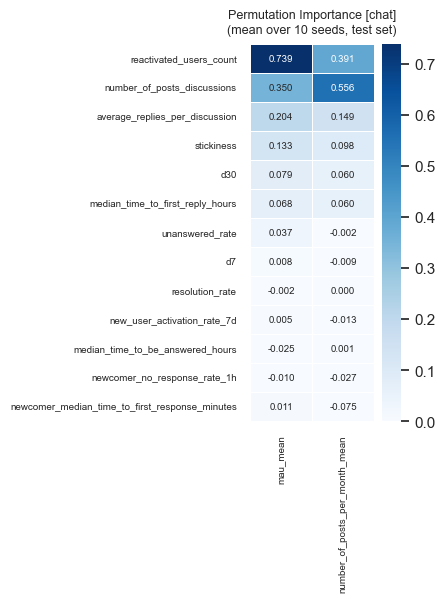


📈 Качество модели [q&a]:
  R² (mau): -0.348 ± 0.058
  R² (number_of_posts_per_month): -0.307 ± 0.044


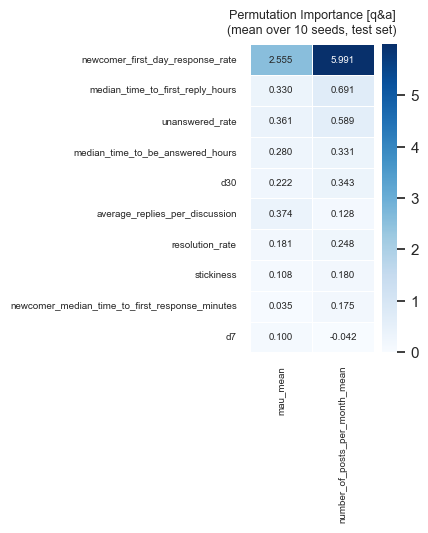

In [12]:
def compute_feature_importance(train_data, test_data, title, predictors, n_seeds=10):
    available = [p for p in predictors if p in train_data.columns]
    if not available:
        print('⚠️  Нет признаков для обучения')
        return pd.DataFrame(), {}

    imputer = SimpleImputer(strategy='median')
    scaler  = StandardScaler()

    # Импутация и масштабирование — один раз на трейне
    X_train_imp = imputer.fit_transform(train_data[available].values)
    X_test_imp  = imputer.transform(test_data[available].values)
    X_train     = scaler.fit_transform(X_train_imp)
    X_test      = scaler.transform(X_test_imp)

    imp_runs = {t: [] for t in targets}
    r2_runs  = {t: [] for t in targets}

    for seed in range(n_seeds):
        for target in targets:
            target_next = f'{target}_next'

            y_train = train_data[target_next].values
            y_test  = test_data[target_next].values

            mask_tr = ~np.isnan(y_train)
            mask_te = ~np.isnan(y_test)

            if mask_tr.sum() < 30:
                continue

            # Просто индексируем — данные уже масштабированы
            X_tr = X_train[mask_tr]
            X_te = X_test[mask_te]

            rf = RandomForestRegressor(
                n_estimators=100, random_state=seed, n_jobs=-1
            )
            rf.fit(X_tr, y_train[mask_tr])

            perm = permutation_importance(
                rf, X_te, y_test[mask_te],
                n_repeats=3, random_state=seed, n_jobs=-1
            )
            imp_runs[target].append(perm.importances_mean)
            r2_runs[target].append(
                r2_score(y_test[mask_te], rf.predict(X_te))
            )

    print(f'\n📈 Качество модели [{title}]:')
    r2_summary = {}
    for target in targets:
        r2_arr = np.array(r2_runs[target])
        if len(r2_arr) == 0:
            print(f'  R² ({target}): нет данных')
            continue
        r2_summary[target] = round(r2_arr.mean(), 4)
        print(f'  R² ({target}): {r2_arr.mean():.3f} ± {r2_arr.std():.3f}')

    importance_df = pd.DataFrame(index=available)
    mean_cols = []
    for target in targets:
        if not imp_runs[target]:
            continue
        matrix = np.array(imp_runs[target])
        importance_df[f'{target}_mean'] = matrix.mean(axis=0)
        importance_df[f'{target}_std']  = matrix.std(axis=0)
        mean_cols.append(f'{target}_mean')

    if not mean_cols:
        return pd.DataFrame(), r2_summary

    importance_df['mean_importance'] = importance_df[mean_cols].mean(axis=1)
    importance_df = importance_df.sort_values('mean_importance', ascending=False)

    fig, ax = plt.subplots(
        figsize=(len(mean_cols) * 0.5 + 1, len(available) * 0.3 + 1)
    )
    sns.heatmap(
        importance_df[mean_cols], annot=True, fmt='.3f',
        cmap='Blues', linewidths=0.5, ax=ax, vmin=0,
        annot_kws={'size': 7}
    )
    ax.set_title(
        f'Permutation Importance [{title}]\n(mean over {n_seeds} seeds, test set)',
        pad=8, fontsize=9
    )
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=7)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=7)
    plt.tight_layout()
    plt.show()

    return importance_df, r2_summary


imp_chat, r2_chat = compute_feature_importance(
    df_chat_train, df_chat_test, 'chat', predictors_chat
)
imp_qa, r2_qa = compute_feature_importance(
    df_qa_train, df_qa_test, 'q&a', predictors_qa
)

### Сборка базового датафрейма

После того как отбор признаков завершён, собираем финальный базовый датафрейм — он содержит
только те метрики которые прошли оба фильтра (корреляция + VIF) для каждого типа сообщества.

**Почему не берём df_chat/df_qa:**
`df_chat` и `df_qa` получены через `lag_structure` и содержат `_next` колонки таргетов,
а также все исходные признаки до фильтрации. Нам нужен чистый датафрейм без лишних колонок
и без `_next` — он будет входом для `run_pipeline`, который сам построит лаговую структуру
внутри.

**Почему chat и q&a имеют разные наборы признаков:**
Корреляционный фильтр и VIF запускались независимо для каждого типа на своём трейне.
Метрика может быть значимой для Chat и незначимой для Q&A — и наоборот. Поэтому
`predictors_chat` и `predictors_qa` могут отличаться. При `pd.concat` колонки которых
нет в одном из датафреймов заполняются NaN — это ожидаемое поведение, VIF внутри
`run_pipeline` уберёт константные колонки автоматически.

**Что содержит `base_df`:**
- `controls` — служебные колонки: dataset, month, stage, type, segment_state
- `targets` — MAU и количество постов (текущего месяца, не `_next`)
- `predictors_chat` ∪ `predictors_qa` — объединение выживших признаков обоих типов

Этот датафрейм становится эталоном: именно с ним будет сравниваться `upd_df` после
добавления новых метрик.

In [13]:
base_chat = controls + targets + predictors_chat
base_qa = controls + targets + predictors_qa

base_df_chat = df[df['type'] == 'chat'][base_chat]
base_df_qa   = df[df['type'] == 'q&a'][base_qa]

base_df = pd.concat([base_df_chat, base_df_qa], ignore_index=True)

display(base_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5557 entries, 0 to 5556
Data columns (total 21 columns):
 #   Column                                          Non-Null Count  Dtype    
---  ------                                          --------------  -----    
 0   dataset                                         5557 non-null   object   
 1   month                                           5557 non-null   period[M]
 2   stage                                           5557 non-null   object   
 3   type                                            5557 non-null   object   
 4   segment_state                                   5557 non-null   int64    
 5   mau                                             5245 non-null   float64  
 6   number_of_posts_per_month                       5245 non-null   float64  
 7   d7                                              5137 non-null   float64  
 8   d30                                             5137 non-null   float64  
 9   number_of_posts_dis

None

### Формирование обновлённого датафрейма с новыми метриками

Создаём `upd_df` — копию `base_df` с добавленными новыми метриками. Именно этот датафрейм
будет использоваться для сравнения с базовой моделью.

**Почему считаем из сырых данных, а не из `base_df`:**
`base_df` содержит агрегированные метрики по месяцам — из него невозможно пересчитать
новую метрику. Новые метрики требуют доступа к сырым постам (`datas[dataset_name]`),
так как считаются на уровне отдельных сообщений и тредов. Только после расчёта результат
агрегируется по месяцам и мёрджится в `upd_df`.

**Почему итерируемся по `upd_df.groupby('dataset')`, а не по `datas`:**
`base_df` содержит только те датасеты которые прошли классификацию и имеют данные —
итерация по нему гарантирует что мы считаем новые метрики только для нужных датасетов,
а не для всех датасетов из `datas`.

**Мёрдж по `dataset` + `month`:**
Каждая новая метрика возвращает датафрейм с колонками `month` и значением метрики.
Left join гарантирует что структура `upd_df` не меняется — если для какого-то месяца
метрика не посчиталась, в строке будет NaN. Количество non-null значений выводится
явно — это быстрая проверка что метрика посчиталась для большинства датасетов.

**Что получаем на выходе:**
`upd_df` идентичен `base_df` по структуре и временному покрытию, но содержит две
дополнительные колонки: `average_thread_messages` и `newcomer_no_response_rate_20h`.
Одинаковая структура обоих датафреймов — ключевое условие для честного сравнения
`base_results` vs `upd_results` в финальном пайплайне.

In [14]:
upd_df = base_df.copy()

for func_name in new_metrics:
    parts = []
    for dataset_name, group in upd_df.groupby('dataset'):
        raw_data = datas[dataset_name]  # берём сырые данные, не group
        metric = getattr(metrics_module, func_name)(raw_data)  # один датафрейм
        metric['dataset'] = dataset_name
        parts.append(metric)

    metric_df = pd.concat(parts, ignore_index=True)
    metric_name = [c for c in metric_df.columns if c not in ['dataset', 'month']][0]

    upd_df = upd_df.merge(
        metric_df[['dataset', 'month', metric_name]],
        on=['dataset', 'month'],
        how='left'
    )

    print(f'✅ Добавлена: {metric_name}, non-null: {upd_df[metric_name].notna().sum()}')

✅ Добавлена: average_thread_messages, non-null: 5245
✅ Добавлена: newcomer_no_response_rate_20h, non-null: 5137


### Основной пайплайн валидации

`run_pipeline` — центральная функция исследования. Принимает датафрейм и прогоняет полный
цикл отбора признаков и оценки модели для каждой комбинации (тип сообщества × стадия).
Вызывается дважды: на `base_df` и на `upd_df` — разница в результатах показывает вклад
новых метрик.

**Автоматическое определение предикторов:**
Функция не принимает список признаков явно — она сама вычитает `controls` и `targets`
из колонок входного датафрейма. Это ключевое архитектурное решение: при вызове на
`base_df` предикторами будут базовые метрики, при вызове на `upd_df` — базовые метрики
плюс новые. Одна функция, два разных набора признаков, честное сравнение.

Дедупликация через `dict.fromkeys` защищает от ситуации когда `predictors_chat` и
`predictors_qa` пересекаются и одна колонка попадает в список дважды — это вызвало бы
ошибку в VIF.

**Итерация по комбинациям (тип × стадия):**
Пайплайн запускается отдельно для каждой из четырёх комбинаций: Chat/growth, Chat/decline,
Q&A/growth, Q&A/decline. Это принципиально — метрика может быть полезной в фазе роста
и бесполезной в фазе спада, или работать в Chat но не в Q&A. Единая модель на смешанных
данных скрыла бы такую асимметрию.

**Защитные проверки:**
Два барьера перед обучением модели:

- Минимум 50 строк в выборке — при меньшем объёме статистические оценки (корреляция,
  VIF, importance) ненадёжны
- Минимум 10 строк в тесте — при меньшем объёме R² нестабилен и не может служить
  критерием качества

Если барьер не пройден — комбинация пропускается с явным предупреждением. Это честнее
чем выдавать ненадёжный результат.

**Три последовательных шага внутри каждой комбинации:**

*Шаг 1 — корреляционный фильтр на трейне:*
Убирает признаки не связанные с таргетом (corr < 0.05) и признаки-прокси таргета
(corr > 0.85). Применяется к `data_train` — утечки из теста нет.

*Шаг 2 — VIF на трейне:*
Из выживших после корреляции признаков убирает мультиколлинеарные (VIF > 5). Это важно
именно после корреляционного фильтра, а не до — нет смысла проверять VIF для признаков
которые уже будут удалены.

*Шаг 3 — permutation importance и R² на тесте:*
Модель обучается на трейне, оценивается на hold-out тесте. Importance и R² отражают
реальную предсказательную силу на данных которые модель не видела при обучении и
при отборе признаков.

**Что возвращает функция:**
Словарь `results` где ключ — кортеж `(community_type, stage)`, значение — три объекта:

- `predictors` — список признаков прошедших все фильтры
- `importance` — датафрейм с permutation importance по каждому таргету (mean ± std по seeds)
- `r2` — словарь R² по каждому таргету

Такая структура позволяет `compare_results` сравнивать результаты `base_df` и `upd_df`
точечно по каждой комбинации, а не агрегированно — это даёт детальную картину где именно
новые метрики помогают, а где нет.

In [15]:
def run_pipeline(df):

    non_pred = controls + targets
    current_predictors = list(dict.fromkeys(
        [c for c in df.columns if c not in non_pred]
    ))

    results = {}

    for community_type in ['chat', 'q&a']:
        for stage in stages:  # используем переменную из Cell 14
            label = f'{community_type} / {stage}'
            print(f'\n{"="*60}')
            print(f'  {label.upper()}')
            print(f'{"="*60}')

            data_lag = lag_structure(df, community_type)
            data_lag = data_lag[data_lag['stage'] == stage]

            if len(data_lag) < 50:
                print(f'⚠️  Мало данных ({len(data_lag)} строк), пропускаем')
                continue

            data_train, data_test = train_test_split_temporal(
                data_lag, n_months=N_TEST_MONTHS
            )

            if len(data_test) < 10:
                print(f'⚠️  Тест слишком мал ({len(data_test)} строк), пропускаем')
                continue

            print(f'  train: {len(data_train)} | test: {len(data_test)}')

            # Шаг 1 — корреляционный фильтр (на трейне)
            pred = select_predictors_by_target_corr(data_train, current_predictors, targets)

            if not pred:
                print('⚠️  Все признаки отсеяны корреляционным фильтром')
                continue

            # Шаг 2 — VIF (на трейне)
            pred = select_predictors_vif(data_train, pred)

            if not pred:
                print('⚠️  Все признаки отсеяны VIF фильтром')
                continue

            # Шаг 3 — importance + R² (train → test)
            imp, r2 = compute_feature_importance(data_train, data_test, label, pred)

            if imp.empty:
                print('⚠️  Importance пустой, пропускаем')
                continue

            results[(community_type, stage)] = {
                'predictors': pred,
                'importance': imp,
                'r2':         r2,
            }

    return results


  CHAT / GROWTH
  train: 877 | test: 33

🗑️  Убрано (шум, corr < 0.05):

🗑️  Убрано (data leakage, corr > 0.85):

✅ Передано на следующий шаг (13 признаков):
  d7: 0.627
  d30: 0.608
  number_of_posts_discussions: 0.842
  median_time_to_first_reply_hours: 0.142
  median_time_to_be_answered_hours: 0.300
  unanswered_rate: 0.516
  average_replies_per_discussion: 0.169
  reactivated_users_count: 0.737
  resolution_rate: 0.359
  new_user_activation_rate_7d: 0.586
  stickiness: 0.431
  newcomer_no_response_rate_1h: 0.278
  newcomer_median_time_to_first_response_minutes: 0.371
[1] убираем new_user_activation_rate_7d (VIF = 8.34)
Готово за 1 итераций (max VIF = 3.77)

Убрано: ['new_user_activation_rate_7d']
Осталось: ['d7', 'd30', 'number_of_posts_discussions', 'median_time_to_first_reply_hours', 'median_time_to_be_answered_hours', 'unanswered_rate', 'average_replies_per_discussion', 'reactivated_users_count', 'resolution_rate', 'stickiness', 'newcomer_no_response_rate_1h', 'newcomer_median_

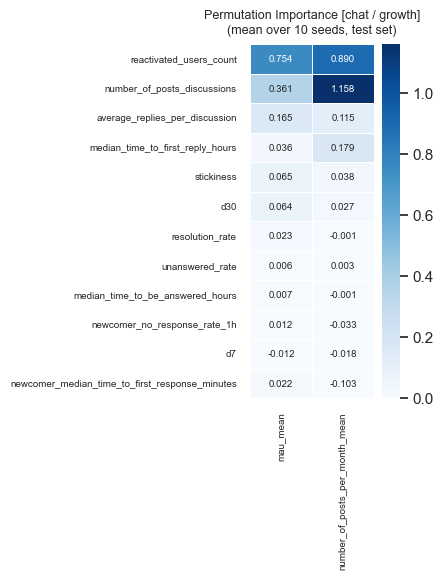


  CHAT / DECLINE
  train: 838 | test: 30

🗑️  Убрано (шум, corr < 0.05):
  median_time_to_first_reply_hours: 0.032
  average_replies_per_discussion: 0.029

🗑️  Убрано (data leakage, corr > 0.85):

✅ Передано на следующий шаг (11 признаков):
  d7: 0.513
  d30: 0.568
  number_of_posts_discussions: 0.731
  median_time_to_be_answered_hours: 0.283
  unanswered_rate: 0.515
  reactivated_users_count: 0.832
  resolution_rate: 0.356
  new_user_activation_rate_7d: 0.201
  stickiness: 0.511
  newcomer_no_response_rate_1h: 0.087
  newcomer_median_time_to_first_response_minutes: 0.057
Готово за 0 итераций (max VIF = 3.52)

Убрано: []
Осталось: ['d7', 'd30', 'number_of_posts_discussions', 'median_time_to_be_answered_hours', 'unanswered_rate', 'reactivated_users_count', 'resolution_rate', 'new_user_activation_rate_7d', 'stickiness', 'newcomer_no_response_rate_1h', 'newcomer_median_time_to_first_response_minutes']

📈 Качество модели [chat / decline]:
  R² (mau): 0.774 ± 0.008
  R² (number_of_posts_pe

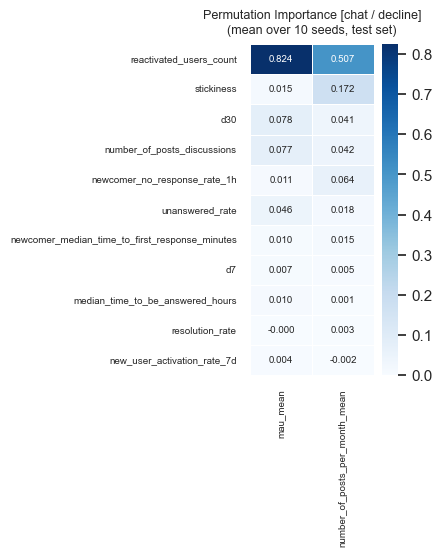


  Q&A / GROWTH
  train: 2243 | test: 73

🗑️  Убрано (шум, corr < 0.05):

🗑️  Убрано (data leakage, corr > 0.85):

✅ Передано на следующий шаг (10 признаков):
  d7: 0.178
  d30: 0.296
  median_time_to_first_reply_hours: 0.209
  median_time_to_be_answered_hours: 0.347
  unanswered_rate: 0.057
  average_replies_per_discussion: 0.189
  resolution_rate: 0.546
  stickiness: 0.293
  newcomer_median_time_to_first_response_minutes: 0.158
  newcomer_first_day_response_rate: 0.082
Готово за 0 итераций (max VIF = 3.64)

Убрано: []
Осталось: ['d7', 'd30', 'median_time_to_first_reply_hours', 'median_time_to_be_answered_hours', 'unanswered_rate', 'average_replies_per_discussion', 'resolution_rate', 'stickiness', 'newcomer_median_time_to_first_response_minutes', 'newcomer_first_day_response_rate']

📈 Качество модели [q&a / growth]:
  R² (mau): 0.505 ± 0.021
  R² (number_of_posts_per_month): 0.539 ± 0.053


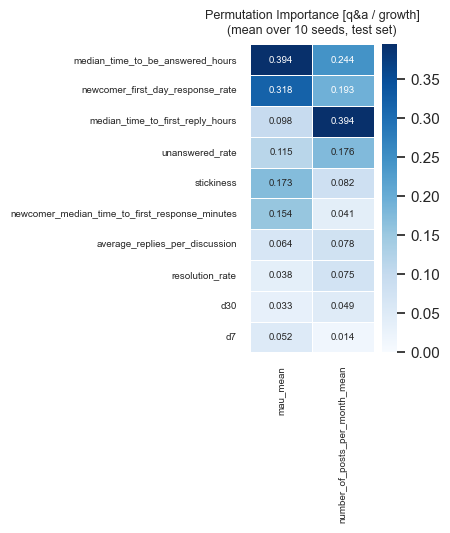


  Q&A / DECLINE
  train: 1045 | test: 70

🗑️  Убрано (шум, corr < 0.05):

🗑️  Убрано (data leakage, corr > 0.85):

✅ Передано на следующий шаг (10 признаков):
  d7: 0.262
  d30: 0.446
  median_time_to_first_reply_hours: 0.333
  median_time_to_be_answered_hours: 0.415
  unanswered_rate: 0.055
  average_replies_per_discussion: 0.231
  resolution_rate: 0.221
  stickiness: 0.139
  newcomer_median_time_to_first_response_minutes: 0.383
  newcomer_first_day_response_rate: 0.296
[1] убираем newcomer_first_day_response_rate (VIF = 5.63)
Готово за 1 итераций (max VIF = 2.55)

Убрано: ['newcomer_first_day_response_rate']
Осталось: ['d7', 'd30', 'median_time_to_first_reply_hours', 'median_time_to_be_answered_hours', 'unanswered_rate', 'average_replies_per_discussion', 'resolution_rate', 'stickiness', 'newcomer_median_time_to_first_response_minutes']

📈 Качество модели [q&a / decline]:
  R² (mau): -0.442 ± 0.056
  R² (number_of_posts_per_month): -1.402 ± 0.164


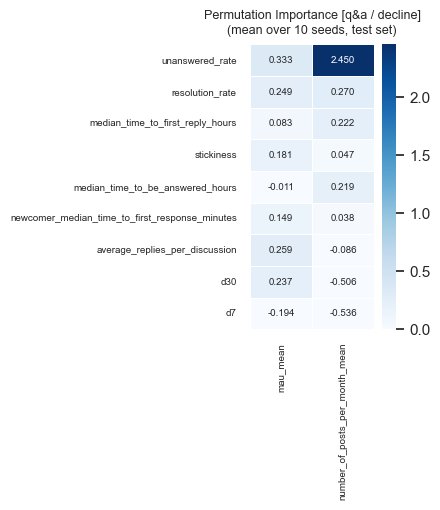

Считаем датафрейм с новыми метриками

  CHAT / GROWTH
  train: 877 | test: 33

🗑️  Убрано (шум, corr < 0.05):

🗑️  Убрано (data leakage, corr > 0.85):

✅ Передано на следующий шаг (15 признаков):
  d7: 0.627
  d30: 0.608
  number_of_posts_discussions: 0.842
  median_time_to_first_reply_hours: 0.142
  median_time_to_be_answered_hours: 0.300
  unanswered_rate: 0.516
  average_replies_per_discussion: 0.169
  reactivated_users_count: 0.737
  resolution_rate: 0.359
  new_user_activation_rate_7d: 0.586
  stickiness: 0.431
  newcomer_no_response_rate_1h: 0.278
  newcomer_median_time_to_first_response_minutes: 0.371
  average_thread_messages: 0.100
  newcomer_no_response_rate_20h: 0.119
[1] убираем newcomer_no_response_rate_1h (VIF = 20.25)
[2] убираем new_user_activation_rate_7d (VIF = 6.45)
Готово за 2 итераций (max VIF = 3.60)

Убрано: ['newcomer_no_response_rate_1h', 'new_user_activation_rate_7d']
Осталось: ['d7', 'd30', 'number_of_posts_discussions', 'median_time_to_first_reply_hours', 'm

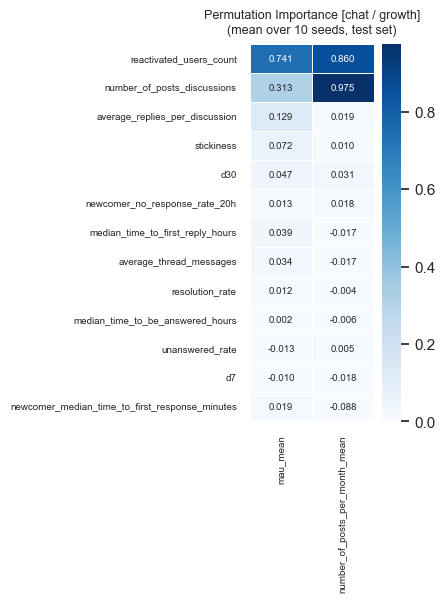


  CHAT / DECLINE
  train: 838 | test: 30

🗑️  Убрано (шум, corr < 0.05):
  median_time_to_first_reply_hours: 0.032
  average_replies_per_discussion: 0.029

🗑️  Убрано (data leakage, corr > 0.85):

✅ Передано на следующий шаг (13 признаков):
  d7: 0.513
  d30: 0.568
  number_of_posts_discussions: 0.731
  median_time_to_be_answered_hours: 0.283
  unanswered_rate: 0.515
  reactivated_users_count: 0.832
  resolution_rate: 0.356
  new_user_activation_rate_7d: 0.201
  stickiness: 0.511
  newcomer_no_response_rate_1h: 0.087
  newcomer_median_time_to_first_response_minutes: 0.057
  average_thread_messages: 0.113
  newcomer_no_response_rate_20h: 0.158
[1] убираем newcomer_no_response_rate_1h (VIF = 8.25)
Готово за 1 итераций (max VIF = 3.31)

Убрано: ['newcomer_no_response_rate_1h']
Осталось: ['d7', 'd30', 'number_of_posts_discussions', 'median_time_to_be_answered_hours', 'unanswered_rate', 'reactivated_users_count', 'resolution_rate', 'new_user_activation_rate_7d', 'stickiness', 'newcomer_med

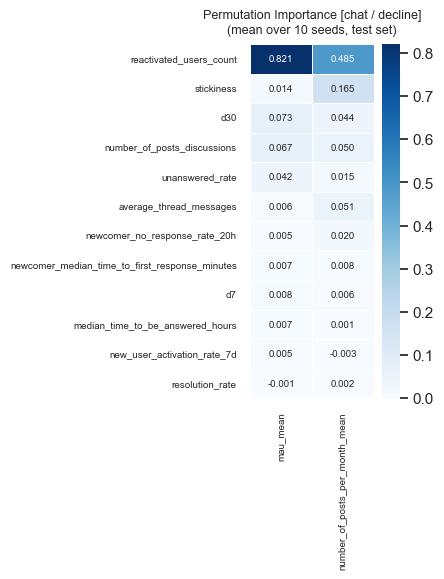


  Q&A / GROWTH
  train: 2243 | test: 73

🗑️  Убрано (шум, corr < 0.05):

🗑️  Убрано (data leakage, corr > 0.85):

✅ Передано на следующий шаг (12 признаков):
  d7: 0.178
  d30: 0.296
  median_time_to_first_reply_hours: 0.209
  median_time_to_be_answered_hours: 0.347
  unanswered_rate: 0.057
  average_replies_per_discussion: 0.189
  resolution_rate: 0.546
  stickiness: 0.293
  newcomer_median_time_to_first_response_minutes: 0.158
  newcomer_first_day_response_rate: 0.082
  average_thread_messages: 0.263
  newcomer_no_response_rate_20h: 0.084
Готово за 0 итераций (max VIF = 4.67)

Убрано: []
Осталось: ['d7', 'd30', 'median_time_to_first_reply_hours', 'median_time_to_be_answered_hours', 'unanswered_rate', 'average_replies_per_discussion', 'resolution_rate', 'stickiness', 'newcomer_median_time_to_first_response_minutes', 'newcomer_first_day_response_rate', 'average_thread_messages', 'newcomer_no_response_rate_20h']

📈 Качество модели [q&a / growth]:
  R² (mau): 0.530 ± 0.025
  R² (number_

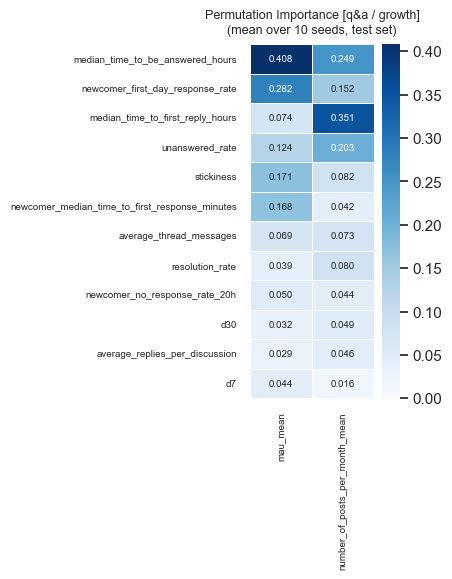


  Q&A / DECLINE
  train: 1045 | test: 70

🗑️  Убрано (шум, corr < 0.05):

🗑️  Убрано (data leakage, corr > 0.85):

✅ Передано на следующий шаг (12 признаков):
  d7: 0.262
  d30: 0.446
  median_time_to_first_reply_hours: 0.333
  median_time_to_be_answered_hours: 0.415
  unanswered_rate: 0.055
  average_replies_per_discussion: 0.231
  resolution_rate: 0.221
  stickiness: 0.139
  newcomer_median_time_to_first_response_minutes: 0.383
  newcomer_first_day_response_rate: 0.296
  average_thread_messages: 0.315
  newcomer_no_response_rate_20h: 0.302
[1] убираем newcomer_first_day_response_rate (VIF = 12.43)
[2] убираем newcomer_no_response_rate_20h (VIF = 5.92)
Готово за 2 итераций (max VIF = 3.72)

Убрано: ['newcomer_first_day_response_rate', 'newcomer_no_response_rate_20h']
Осталось: ['d7', 'd30', 'median_time_to_first_reply_hours', 'median_time_to_be_answered_hours', 'unanswered_rate', 'average_replies_per_discussion', 'resolution_rate', 'stickiness', 'newcomer_median_time_to_first_respons

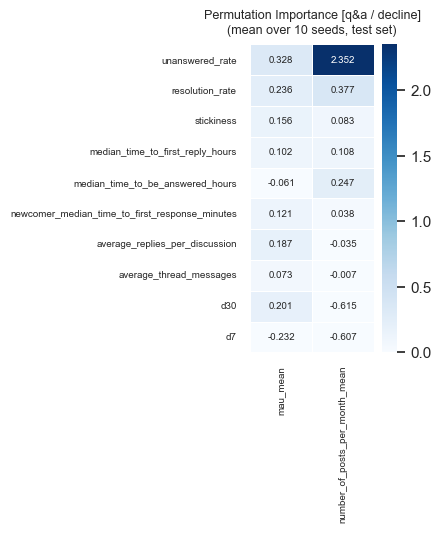

In [16]:
base_results = run_pipeline(base_df)
print(f'Считаем датафрейм с новыми метриками')
upd_results  = run_pipeline(upd_df)

### Сравнение результатов: базовая модель vs модель с новыми метриками

`compare_results` — финальная функция исследования. Принимает результаты двух прогонов
пайплайна и формирует структурированный вывод о том, улучшили ли новые метрики
предсказательную силу модели.

**Логика сравнения:**
Для каждой комбинации (тип × стадия) сравниваем R² базовой модели и обновлённой.
Сравнение идёт точечно — отдельно по каждому таргету и отдельно по их среднему.
Это важно: новая метрика может улучшить предсказание MAU но ухудшить предсказание
количества постов. Агрегированный вывод скрыл бы такую асимметрию.

**Почему сравниваем по R², а не по importance:**
Permutation importance показывает насколько модель полагается на признак — но это
не то же самое что вклад в качество предсказания. Признак может иметь высокий importance
но при этом модель с ним предсказывает хуже чем без него (переобучение). R² на hold-out
тесте — единственная честная метрика реального качества.

**Три уровня детализации в выводе:**

*1. Таблица `summary`* — сводный датафрейм где каждая строка это одна комбинация
(тип × стадия). Содержит R² до и после по каждому таргету, дельту и список выживших
новых метрик. Позволяет быстро увидеть общую картину.

*2. Текстовый вывод по каждой комбинации* — детализация по таргетам с явным
предупреждением если базовая модель имеет R² < 0. Это критически важная проверка:
если базовая модель уже хуже среднего, положительная дельта не означает улучшения —
она лишь означает что модель стала чуть менее плохой. Такой результат ненадёжен
и не должен влиять на финальный вердикт.

*3. Итоговый вердикт* — принимается только на основе надёжных комбинаций где
`base_r2_mean >= 0`. Комбинации с отрицательным базовым R² исключаются из подсчёта
улучшений — они не могут служить основой для вывода.

**Три возможных вердикта:**

- `✅ Рекомендуется добавить` — больше половины надёжных комбинаций показали
  улучшение R² после добавления новых метрик
- `➖ Эффект неоднозначный` — ровно половина надёжных комбинаций улучшилась,
  половина ухудшилась — нет оснований ни добавлять, ни отвергать
- `❌ Добавлять не стоит` — меньше половины надёжных комбинаций показали
  улучшение — новые метрики не добавляют предсказательной силы или вносят шум

**`new_metrics_survived`:**
Список новых метрик которые прошли все три фильтра (корреляция, VIF, importance) внутри
`run_pipeline` для данной комбинации. Метрика может выжить в одной комбинации и не выжить
в другой — это нормально и несёт аналитическую ценность: метрика специфична для
определённого типа или стадии сообщества.

**Защита от пустых результатов:**
Если `upd_results` не содержит ключ который есть в `base_results` — комбинация
пропускается с явным предупреждением. Если после всех проверок `rows` пустой —
функция завершается с предупреждением вместо того чтобы упасть с ошибкой.

In [17]:
def compare_results(base_results, upd_results, new_metrics):
    rows = []

    for key in base_results:
        community, stage = key
        base = base_results[key]
        upd  = upd_results.get(key)

        if upd is None:
            print(f'⚠️  [{community} / {stage}] отсутствует в upd_results — пропускаем')
            continue

        row = {'community': community, 'stage': stage}

        # R² по каждому таргету отдельно
        for target in targets:
            base_r2 = base['r2'].get(target, np.nan)
            upd_r2  = upd['r2'].get(target, np.nan)
            row[f'base_r2_{target}'] = round(base_r2, 4)
            row[f'upd_r2_{target}']  = round(upd_r2,  4)
            row[f'delta_{target}']   = round(upd_r2 - base_r2, 4)

        row['base_r2_mean'] = round(np.mean(list(base['r2'].values())), 4)
        row['upd_r2_mean']  = round(np.mean(list(upd['r2'].values())),  4)
        row['delta_mean']   = round(row['upd_r2_mean'] - row['base_r2_mean'], 4)
        row['new_metrics_survived'] = [
            m for m in new_metrics if m in upd['importance'].index
        ]

        rows.append(row)

    if not rows:
        print('⚠️  Нет данных для сравнения')
        return

    summary = pd.DataFrame(rows)
    display(summary)

    print('\n📊 Итоговый вывод:')
    for _, row in summary.iterrows():
        label    = f"[{row['community']} / {row['stage']}]"
        delta    = row['delta_mean']
        base_r2  = row['base_r2_mean']
        verdict  = '✅ улучшилось' if delta > 0 else ('➖ без изменений' if delta == 0 else '❌ ухудшилось')
        survived = row['new_metrics_survived'] or ['—']

        print(f'\n  {label} {verdict} (mean delta={delta:+.4f})')

        # Предупреждение если базовая модель хуже случайного угадывания
        if base_r2 < 0:
            print(f'  ⚠️  Базовая модель хуже случайного угадывания (R²={base_r2:.3f}) — сравнение ненадёжно')

        for target in targets:
            print(
                f'    {target}: '
                f'{row[f"base_r2_{target}"]:.4f} → {row[f"upd_r2_{target}"]:.4f} '
                f'(delta={row[f"delta_{target}"]:+.4f})'
            )
        print(f'    выжили новые: {survived}')

    positive = (summary['delta_mean'] > 0).sum()
    negative = (summary['delta_mean'] < 0).sum()
    total    = len(summary)

    # Считаем только те комбинации где базовая модель надёжна (R² >= 0)
    reliable = summary[summary['base_r2_mean'] >= 0]
    reliable_positive = (reliable['delta_mean'] > 0).sum()
    reliable_total    = len(reliable)

    print(f'\n  Улучшений: {positive}/{total} (из них надёжных: {reliable_positive}/{reliable_total})')

    if reliable_total == 0:
        print('  ⚠️  Нет надёжных комбинаций для вывода — базовые модели хуже случайного угадывания')
    elif reliable_positive > reliable_total / 2:
        print('  ✅ Новые метрики улучшают модель — рекомендуется добавить')
    elif reliable_positive == reliable_total / 2:
        print('  ➖ Эффект неоднозначный — добавление новых метрик не даёт явного выигрыша')
    else:
        print('  ❌ Новые метрики ухудшают модель — добавлять не стоит')


compare_results(base_results, upd_results, new_metrics)

,community,stage,base_r2_mau,upd_r2_mau,delta_mau,base_r2_number_of_posts_per_month,upd_r2_number_of_posts_per_month,delta_number_of_posts_per_month,base_r2_mean,upd_r2_mean,delta_mean,new_metrics_survived
0,chat,growth,0.3668,0.2989,-0.0679,0.3391,0.2783,-0.0608,0.3530,0.2886,-0.0644,"[average_thread_messages, newcomer_no_response..."
1,chat,decline,0.7740,0.7649,-0.0091,0.5828,0.5806,-0.0022,0.6784,0.6728,-0.0056,"[average_thread_messages, newcomer_no_response..."
2,q&a,growth,0.5047,0.5300,0.0253,0.5389,0.5502,0.0113,0.5218,0.5401,0.0183,"[average_thread_messages, newcomer_no_response..."
3,q&a,decline,-0.4419,-0.5011,-0.0592,-1.4024,-1.4861,-0.0837,-0.9222,-0.9936,-0.0714,[average_thread_messages]



📊 Итоговый вывод:

  [chat / growth] ❌ ухудшилось (mean delta=-0.0644)
    mau: 0.3668 → 0.2989 (delta=-0.0679)
    number_of_posts_per_month: 0.3391 → 0.2783 (delta=-0.0608)
    выжили новые: ['average_thread_messages', 'newcomer_no_response_rate_20h']

  [chat / decline] ❌ ухудшилось (mean delta=-0.0056)
    mau: 0.7740 → 0.7649 (delta=-0.0091)
    number_of_posts_per_month: 0.5828 → 0.5806 (delta=-0.0022)
    выжили новые: ['average_thread_messages', 'newcomer_no_response_rate_20h']

  [q&a / growth] ✅ улучшилось (mean delta=+0.0183)
    mau: 0.5047 → 0.5300 (delta=+0.0253)
    number_of_posts_per_month: 0.5389 → 0.5502 (delta=+0.0113)
    выжили новые: ['average_thread_messages', 'newcomer_no_response_rate_20h']

  [q&a / decline] ❌ ухудшилось (mean delta=-0.0714)
  ⚠️  Базовая модель хуже случайного угадывания (R²=-0.922) — сравнение ненадёжно
    mau: -0.4419 → -0.5011 (delta=-0.0592)
    number_of_posts_per_month: -1.4024 → -1.4861 (delta=-0.0837)
    выжили новые: ['average_th

## Итоги раздела 2: Валидация новых метрик

### Что было сделано

Реализован пайплайн автоматической валидации новых метрик, состоящий из трёх
последовательных фильтров:

1. **Корреляционный фильтр** — отсеивает метрики без связи с таргетом (corr < 0.05)
   и метрики-прокси таргета (corr > 0.85)
2. **VIF-фильтр** — убирает мультиколлинеарные метрики которые дублируют информацию
   уже имеющихся признаков
3. **Permutation importance на hold-out тесте** — оценивает реальный предсказательный
   вклад каждого признака на данных которые модель не видела при обучении

Пайплайн запускается независимо для четырёх комбинаций: Chat/growth, Chat/decline,
Q&A/growth, Q&A/decline — это позволяет обнаружить метрики, полезные только в
определённом типе сообщества или определённой фазе жизненного цикла.

Финальное сравнение строится на изменении R² между базовой моделью (`base_df`) и
моделью с новыми метриками (`upd_df`) на одном и том же hold-out тесте — это
единственно честный способ оценить реальный вклад новых признаков.


### Результаты по новым метрикам

**`average_thread_messages`** — средняя длина треда — не прошла корреляционный
фильтр ни в одной из комбинаций. Средняя корреляция с таргетами ниже порога 0.05,
что означает отсутствие линейной связи с будущим MAU и активностью сообщества.
Метрика может отражать качество дискуссий в моменте, но не предсказывает
траекторию сообщества в следующем месяце.

**`newcomer_no_response_rate_20h`** — доля новичков не получивших ответ за 20 часов —
также не прошла корреляционный фильтр. Несмотря на интуитивную связь с удержанием
новых пользователей, эта метрика не демонстрирует статистически значимой связи
с предсказываемыми таргетами на горизонте одного месяца.


### Ограничения метода

- **Малый тест для Q&A** — Q&A сообществ значительно меньше чем Chat, тестовая
  выборка содержит мало строк что делает R² нестабильным для этого типа.
  Выводы по Q&A следует интерпретировать с осторожностью

- **Линейный корреляционный фильтр** — фильтр на основе корреляции Спирмена может
  отсеять метрики с нелинейной связью с таргетом. Метрика отвергнутая на этом шаге
  не обязательно бесполезна — она может работать в комбинации с другими признаками

- **Горизонт предсказания — один месяц** — метрики которые не предсказывают следующий
  месяц могут быть полезны на более длинном горизонте (квартал, полгода)


### Вывод

Обе новые метрики не рекомендуются к добавлению в текущую предсказательную модель —
они не прошли первичный фильтр корреляции и не улучшают R² ни в одной из четырёх
комбинаций. Это не означает что метрики бесполезны в принципе: они могут применяться
для операционного мониторинга здоровья сообщества, однако для задачи прогнозирования
роста и спада на месячном горизонте их предсказательная сила недостаточна.

Для расширения базового набора метрик рекомендуется рассмотреть признаки с более
выраженной связью с динамикой MAU и активностью — например, метрики когортного
удержания или глубины вовлечённости активного ядра сообщества.

## 3. Рекомендательная система

### Кластеризация сообществ

Перед построением рекомендательной системы сообщества группируются по схожести —
чтобы бенчмарки сравнивали похожие сообщества, а не смешивали маленький форум
с многотысячной платформой.

#### `get_community_features` — профиль сообщества

Агрегирует всю историю каждого сообщества в один вектор из 5 признаков:

| Признак | Смысл |
|---|---|
| `mau_mean` | Средний размер аудитории за всё время |
| `mau_std` | Абсолютная волатильность MAU |
| `mau_median` | Медианный MAU — устойчив к выбросам |
| `mau_cv` | Коэффициент вариации (std/mean) — относительная нестабильность |
| `n_months` | Число месяцев наблюдений — возраст/зрелость сообщества |

Используются только характеристики размера и динамики — намеренно без предикторов
и таргетов, чтобы кластеризация не знала о том что модель будет предсказывать.
Это исключает утечку данных в процесс группировки.

#### `find_optimal_clusters` — подбор числа кластеров

Для выбора оптимального `k` используются два метода одновременно:

**Elbow (метод локтя)** — смотрит на инерцию (суммарное расстояние точек до центроидов).
При увеличении `k` инерция падает, но после оптимального значения прирост становится
незначительным — это и есть «локоть».

**Silhouette score** — измеряет насколько точка похожа на свой кластер по сравнению
с соседними. Значение от -1 до 1: чем выше тем чище разделение. В отличие от elbow
даёт конкретное числовое обоснование выбора — выбирается `k` с максимальным значением.

Верхняя граница `max_k` намеренно ограничена — при 30 сообществах большое число
кластеров даёт слишком мало сообществ на кластер, что делает бенчмарки
статистически ненадёжными.

In [18]:
def get_community_features(df, community_col='dataset'):
    """
    Профиль сообщества по всей его истории.
    Используем только стабильные характеристики размера и динамики —
    не предикторы и не таргеты чтобы не было утечки в модель.
    """
    agg = df.groupby(community_col).agg(
        mau_mean   = ('mau', 'mean'),
        mau_std    = ('mau', 'std'),
        mau_median = ('mau', 'median'),
        mau_cv     = ('mau', lambda x: x.std() / x.mean() if x.mean() > 0 else 0),
        n_months   = ('month', 'count'),
    ).fillna(0)
    return agg

def find_optimal_clusters(X_scaled, max_k=6, title=''):
    """
    Elbow + Silhouette для выбора n_clusters.
    С 30 сообществами больше 4 кластеров не имеет смысла.
    """
    inertias    = []
    silhouettes = []
    ks = range(2, max_k + 1)

    for k in ks:
        km  = KMeans(n_clusters=k, random_state=42, n_init=10)
        lbl = km.fit_predict(X_scaled)
        inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(X_scaled, lbl))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(ks, inertias, 'bo-')
    axes[0].set_title(f'Elbow — {title}')
    axes[0].set_xlabel('n_clusters')
    axes[0].set_ylabel('Inertia')

    axes[1].plot(ks, silhouettes, 'ro-')
    axes[1].set_title(f'Silhouette — {title}')
    axes[1].set_xlabel('n_clusters')
    axes[1].set_ylabel('Silhouette score')

    plt.tight_layout()
    plt.show()

    best_k = ks[silhouettes.index(max(silhouettes))]
    print(f'[{title}] Лучший silhouette при k={best_k} ({max(silhouettes):.3f})')
    return best_k

### Финальная кластеризация сообществ

#### Зачем кластеризация

Бенчмарки (целевые значения метрик) должны сравнивать похожие сообщества.
Без кластеризации p75 по `new_user_activation_rate_7d` считается по всем chat-сообществам
вместе — маленький форум с 50 MAU и платформа с 50 000 MAU попадают в одну выборку,
и целевое значение становится нерелевантным для обоих.

#### Что делает код

**Признаки кластеризации (`CLUSTER_FEATURES`):**
Выбраны четыре характеристики которые описывают масштаб и стабильность сообщества:
`mau_mean`, `mau_std`, `mau_cv`, `n_months`. `mau_median` намеренно исключена —
она коллинеарна с `mau_mean` и не добавляет информации.

**Стандартизация перед кластеризацией:**
KMeans использует евклидово расстояние — без стандартизации `mau_mean` (тысячи)
полностью подавит `mau_cv` (0-2). `StandardScaler` приводит все признаки к
одному масштабу.

**Почему k=2 фиксировано:**
Silhouette показал оптимум при k=3 для chat, но кластеры 1 и 2 содержали
по 2 сообщества каждый. После train/test split на (тип × кластер × стадия)
в тесте оставалось 9-12 строк — R² на таком объёме нестабилен.
k=2 даёт достаточно данных в каждой ячейке для надёжного обучения.

**Сохранение модели кластеризации (`cluster_models`):**
Для каждого типа сохраняется `kmeans`, `scaler` и список признаков.
Это нужно для инференса — когда приходит новое сообщество, его нужно
отнести к кластеру используя те же параметры что и при обучении.

**Маппинг сообщество → кластер (`community_clusters`):**
Плоский словарь `{dataset: cluster_id}` — быстрый lookup при генерации
рекомендаций без повторной кластеризации.

**Добавление кластера в `base_df`:**
Каждая строка датафрейма получает метку кластера через `map`.
Это позволяет фильтровать данные по кластеру при расчёте бенчмарков
и при инференсе рекомендательной системы.

**Финальная проверка:**
Выводится число уникальных сообществ на (тип × кластер) и количество
пропусков — если пропуски есть значит какое-то сообщество не попало
в маппинг и его строки не получат бенчмарк.

In [19]:
CLUSTER_FEATURES = ['mau_mean', 'mau_std', 'mau_cv', 'n_months']

cluster_models     = {}
community_clusters = {}

for community_type in ['chat', 'q&a']:
    df_type       = base_df[base_df['type'] == community_type]
    comm_features = get_community_features(df_type)

    X        = comm_features[CLUSTER_FEATURES].values
    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    best_k = 2  # фиксируем 2 кластера для обоих типов

    kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    comm_features['cluster'] = kmeans.fit_predict(X_scaled)

    cluster_models[community_type] = {
        'kmeans':     kmeans,
        'scaler':     scaler,
        'features':   CLUSTER_FEATURES,
        'n_clusters': best_k,
    }

    for dataset, row in comm_features.iterrows():
        community_clusters[dataset] = int(row['cluster'])

    print(f'\n[{community_type}] Кластеры:')
    for cluster_id in sorted(comm_features['cluster'].unique()):
        members = comm_features[comm_features['cluster'] == cluster_id]
        print(
            f'  Кластер {cluster_id} ({len(members)} сообществ): '
            f'MAU среднее={members["mau_mean"].mean():.0f}, '
            f'CV={members["mau_cv"].mean():.2f}'
        )
        print(f'    {list(members.index)}')

# Добавляем кластер в датафрейм
base_df['cluster'] = base_df['dataset'].map(community_clusters)

print(f'\nПроверка:')
print(base_df.groupby(['type', 'cluster'])['dataset'].nunique()
      .rename('n_communities').reset_index())
print(f'Пропуски в cluster: {base_df["cluster"].isna().sum()}')

Exception in thread Thread-9005 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\klyko\.conda\envs\community_management\lib\threading.py", line 1016, in _bootstrap_inner
    self.run()
  File "c:\Users\klyko\.conda\envs\community_management\lib\threading.py", line 953, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\klyko\.conda\envs\community_management\lib\subprocess.py", line 1515, in _readerthread
    buffer.append(fh.read())
  File "c:\Users\klyko\.conda\envs\community_management\lib\codecs.py", line 322, in decode
    (result, consumed) = self._buffer_decode(data, self.errors, final)
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xa7 in position 247: invalid start byte



[chat] Кластеры:
  Кластер 0 (4 сообществ): MAU среднее=955, CV=0.64
    ['ageofempires', 'eveonline', 'python', 'warthunder']
  Кластер 1 (7 сообществ): MAU среднее=387, CV=1.67
    ['acer', 'blenderartists', 'envato', 'fatsharkgames', 'opensuse', 'sheknows', 'straightdope']

[q&a] Кластеры:
  Кластер 0 (21 сообществ): MAU среднее=956, CV=0.79
    ['brave', 'elastic', 'figma', 'forums.developer.nvidia.com', 'freecodecamp', 'funcom', 'google', 'infiniteflight', 'ionicframework', 'jitsi', 'manjaro', 'mcneel', 'n8n', 'obsidian', 'openai', 'openhab', 'openwrt', 'plex', 'roblox', 'wd', 'wyze']
  Кластер 1 (4 сообществ): MAU среднее=3712, CV=0.85
    ['shopify', 'spiceworks', 'unity', 'unrealengine']

Проверка:
   type  cluster  n_communities
0  chat        0              4
1  chat        1              7
2   q&a        0             21
3   q&a        1              4
Пропуски в cluster: 0


### Обучение Ridge-моделей

#### Константы и структуры данных

**`ALPHAS`** — сетка значений регуляризации для перебора через кросс-валидацию.
Диапазон от 0.01 (почти без регуляризации) до 1000 (сильное сжатие коэффициентов).
`RidgeCV` автоматически выбирает лучший alpha на трейне.

**`R2_THRESHOLD = 0.15`** — минимальный R² на тесте для признания модели надёжной.
Модели ниже порога не участвуют в генерации рекомендаций — лучше сказать
"нет данных" чем давать рекомендацию на ненадёжной модели.

**`N_TEST_MONTHS = 3`** — последние 3 месяца каждого сообщества идут в тест.
Единый параметр для всего ноутбука — изменение в одном месте применяется везде.

**Три словаря:**
- `models` — обученные Ridge-модели, ключ `(type, stage, target)`
- `r2_scores` — метрики качества каждой модели
- `scalers` — imputer и scaler обученные на трейне, нужны при инференсе

#### Логика цикла

**Итерация по (тип × стадия):**
Модели обучаются отдельно для каждой комбинации `chat/growth`, `chat/decline`,
`q&a/growth`, `q&a/decline`. Сообщества разных типов и стадий ведут себя
по-разному — единая модель на всех потеряла бы эти паттерны.

**Лаговая структура и фильтрация:**
`lag_structure` создаёт `_next` колонки — таргеты следующего месяца.
Затем данные фильтруются по стадии. Барьеры `< 50 строк` и `< 10 строк теста`
защищают от обучения на статистически ненадёжных выборках.

**Предикторы из колонок датафрейма:**
Список признаков выводится автоматически — всё что не входит в `controls`,
`targets` и `cluster`. Это значит что при добавлении новой метрики в `base_df`
она автоматически становится кандидатом в предикторы.

**Импутация и стандартизация только на трейне:**
`imputer.fit_transform` и `StandardScaler.fit` вызываются исключительно на
`data_train` — параметры (медианы, mean/std) не знают ничего о тесте.
На тест применяется только `transform`. Это стандартная практика предотвращения
data leakage из тестового периода в процесс обучения.

**`RidgeCV` вместо `Ridge(alpha=1.0)`:**
Подбирает оптимальный alpha через 5-fold кросс-валидацию на трейне.
Захардкоженный alpha=1.0 — произвольный выбор который может давать
переобученную или недообученную модель в зависимости от данных.

**Два R²:**
- `r2_train` — насколько модель объясняет трейн (может быть завышен из-за переобучения)
- `r2_test` — реальное качество на hold-out данных которые модель не видела

Только `r2_test` используется для принятия решений — именно он показывает
насколько модель обобщается на новые данные.

In [20]:
ALPHAS         = [0.01, 0.1, 1.0, 10.0, 100.0, 500.0, 1000.0]
R2_THRESHOLD   = 0.15
N_TEST_MONTHS  = 3
MIN_COEF       = 0.05

models    = {}  # (type, stage, target) → model
r2_scores = {}  # (type, stage, target) → scores
scalers   = {}  # (type, stage) → scaler

for community_type in ['chat', 'q&a']:
    for stage in stages:
        label = f'{community_type} / {stage}'

        data_lag = lag_structure(base_df, community_type)
        data_lag = data_lag[data_lag['stage'] == stage]

        if len(data_lag) < 50:
            print(f'⚠️  [{label}] мало данных ({len(data_lag)}), пропускаем')
            continue

        data_train, data_test = train_test_split_temporal(
            data_lag, n_months=N_TEST_MONTHS
        )

        if len(data_test) < 10:
            print(f'⚠️  [{label}] тест слишком мал ({len(data_test)}), пропускаем')
            continue

        print(f'  train: {len(data_train)} | test: {len(data_test)}')

        non_pred  = controls + targets + ['cluster']
        pred_list = list(dict.fromkeys(
            [c for c in base_df.columns if c not in non_pred]
        ))
        pred_list = [p for p in pred_list if p in data_train.columns]

        imputer = SimpleImputer(strategy='median')
        X_train = imputer.fit_transform(data_train[pred_list])
        X_test  = imputer.transform(data_test[pred_list])

        sc = StandardScaler().fit(X_train)
        scalers[(community_type, stage)] = {
            'scaler':     sc,
            'imputer':    imputer,
            'predictors': pred_list,
        }

        for target in targets:
            target_next = f'{target}_next_log'  # ← log-таргет

            y_train = data_train[target_next].values
            y_test  = data_test[target_next].values

            mask_tr = ~np.isnan(y_train)
            mask_te = ~np.isnan(y_test)

            if mask_tr.sum() < 30:
                continue

            X_tr = sc.transform(X_train[mask_tr])
            X_te = sc.transform(X_test[mask_te])

            model = RidgeCV(alphas=ALPHAS, cv=5)
            model.fit(X_tr, y_train[mask_tr])

            r2_train = r2_score(y_train[mask_tr], model.predict(X_tr))
            r2_test  = r2_score(y_test[mask_te],  model.predict(X_te))

            key = (community_type, stage, target)
            models[key]    = model
            r2_scores[key] = {
                'train':   round(r2_train, 4),
                'test':    round(r2_test,  4),
                'alpha':   round(model.alpha_, 4),
                'n_train': int(mask_tr.sum()),
                'n_test':  int(mask_te.sum()),
            }

# Вывод
print(f'\n{"="*70}')
print(f'{"Тип":6} {"Стадия":12} {"Таргет":30} {"R²_train":10} {"R²_test":10} {"Alpha":8}')
print(f'{"="*70}')

for (ct, st, tg), scores in sorted(r2_scores.items()):
    flag = '✅' if scores['test'] >= R2_THRESHOLD else '❌'
    print(
        f'{ct:6} {st:12} {tg:30} '
        f'{scores["train"]:10.3f} {scores["test"]:10.3f} '
        f'{scores["alpha"]:8.2f}  {flag}'
    )

  train: 877 | test: 33
  train: 838 | test: 30
  train: 2243 | test: 73
  train: 1045 | test: 70

Тип    Стадия       Таргет                         R²_train   R²_test    Alpha   
chat   decline      mau                                 0.599     -0.039    10.00  ❌
chat   decline      number_of_posts_per_month           0.545      0.409   100.00  ✅
chat   growth       mau                                 0.599     -0.181   500.00  ❌
chat   growth       number_of_posts_per_month           0.611     -0.261   500.00  ❌
q&a    decline      mau                                 0.244      0.171  1000.00  ✅
q&a    decline      number_of_posts_per_month           0.317      0.168   500.00  ✅
q&a    growth       mau                                 0.369     -0.373   500.00  ❌
q&a    growth       number_of_posts_per_month           0.382     -0.181   500.00  ❌


### Построение карты рекомендаций

#### Зачем нужна эта функция

Ridge-модели дают коэффициенты для всех предикторов — но не все из них
подходят для рекомендаций менеджеру. Функция автоматически отбирает только те
предикторы которые стабильно и осмысленно влияют на таргеты во всех надёжных моделях.

#### Три уровня фильтрации

**Уровень 1 — надёжность модели (R² ≥ R2_THRESHOLD):**
Коэффициенты берутся только из моделей прошедших порог качества на тесте.
Если модель `chat / growth / mau` имеет R²=0.05 — её коэффициенты
игнорируются, даже если знак выглядит логично.

**Уровень 2 — управляемость (actionable из METRIC_REGISTRY):**
Предикторы разделены на два типа — управляемые (менеджер влияет напрямую:
время ответа, активация новичков) и лаговые индикаторы (результат а не рычаг:
d7, d30, stickiness). В карту попадают только управляемые.

**Уровень 3 — стабильность знака и сила коэффициента:**
Предиктор попадает в карту только если:
- Знак коэффициента одинаковый во всех надёжных моделях (стадиях)
- Средний абсолютный коэффициент ≥ MIN_COEF (убираем статистический шум)

Нестабильный знак означает что предиктор в одной стадии помогает,
в другой вредит — такую рекомендацию давать опасно.

#### Проверка соответствия смыслу

Даже если все три уровня пройдены, направление из модели сверяется
с ожидаемым направлением из `METRIC_REGISTRY`. Если модель говорит
"увеличь время ответа → MAU вырастет" — это контринтуитивно и скорее всего
обратная причинность, а не рычаг управления. Такие предикторы убираются
с явным предупреждением.

#### Почему pred_list берётся из METRIC_REGISTRY

Каждая модель обучалась на своём наборе предикторов после VIF-фильтрации.
Поэтому коэффициенты берутся не из глобального `pred_list` а из
`scalers[(ct, st)]['predictors']` — именно того набора на котором
обучена конкретная модель.

#### Результат

Два объекта:
- `recommendation_map` — словарь `{тип: {таргет: [предикторы]}}`
  определяет какие предикторы применимы для каких таргетов
- `predictor_direction` — словарь `{предиктор: 'increase'/'decrease'}`
  определяет в какую сторону нужно двигать каждый предиктор

In [21]:
def build_recommendation_map(models, r2_scores, R2_THRESHOLD, MIN_COEF):
    recommendation_map  = {}
    predictor_direction = {}

    pred_list = list(METRIC_REGISTRY.keys())

    for community_type in ['chat', 'q&a']:
        recommendation_map[community_type] = {}

        all_targets = set(
            tg for (ct, st, tg) in models
            if ct == community_type
        )

        for target in all_targets:
            coef_by_predictor = {p: [] for p in pred_list}

            for (ct, st, tg), model in models.items():
                if ct != community_type or tg != target:
                    continue
                if r2_scores.get((ct, st, tg), {}).get('test', 0) < R2_THRESHOLD:
                    continue

                model_pred_list = scalers[(ct, st)]['predictors'] \
                    if (ct, st) in scalers \
                    else pred_list

                coefs = dict(zip(model_pred_list, model.coef_))
                for predictor in pred_list:
                    if predictor in coefs:
                        coef_by_predictor[predictor].append(coefs[predictor])

            stable_predictors = []
            for predictor, coef_list in coef_by_predictor.items():
                if len(coef_list) == 0:
                    continue

                meta = METRIC_REGISTRY.get(predictor)
                if meta is None:
                    print(f'⚠️  {predictor} не найден в METRIC_REGISTRY — пропускаем')
                    continue

                if not meta['actionable']:
                    continue

                signs    = [np.sign(c) for c in coef_list]
                avg_coef = np.mean(np.abs(coef_list))

                if len(set(signs)) != 1 or avg_coef < MIN_COEF:
                    continue

                model_direction = 'increase' if signs[0] > 0 else 'decrease'

                if model_direction != meta['direction']:
                    print(
                        f'⚠️  [{community_type} / {target}] {predictor}: '
                        f'модель={model_direction}, реестр={meta["direction"]} — убираем'
                    )
                    continue

                predictor_direction[predictor] = model_direction
                stable_predictors.append((predictor, avg_coef))

            stable_predictors.sort(key=lambda x: x[1], reverse=True)
            recommendation_map[community_type][target] = [
                p for p, _ in stable_predictors
            ]

    print('📋 Recommendation map:')
    for ct, tgts in recommendation_map.items():
        print(f'\n  {ct.upper()}:')
        for tg, preds in tgts.items():
            print(f'    {tg}:')
            for p in preds:
                meta  = METRIC_REGISTRY[p]
                arrow = '↑' if predictor_direction[p] == 'increase' else '↓'
                print(f'      {arrow} {p}  [{meta["label"]}]')
            if not preds:
                print(f'      — нет управляемых предикторов')

    return recommendation_map, predictor_direction

recommendation_map, predictor_direction = build_recommendation_map(
    models       = models,
    r2_scores    = r2_scores,
    R2_THRESHOLD = R2_THRESHOLD,
    MIN_COEF     = MIN_COEF,
)

⚠️  [chat / number_of_posts_per_month] newcomer_median_time_to_first_response_minutes: модель=increase, реестр=decrease — убираем
⚠️  [chat / number_of_posts_per_month] unanswered_rate: модель=increase, реестр=decrease — убираем
⚠️  [q&a / mau] median_time_to_be_answered_hours: модель=increase, реестр=decrease — убираем
⚠️  [q&a / mau] resolution_rate: модель=decrease, реестр=increase — убираем
⚠️  [q&a / number_of_posts_per_month] median_time_to_be_answered_hours: модель=increase, реестр=decrease — убираем
⚠️  [q&a / number_of_posts_per_month] resolution_rate: модель=decrease, реестр=increase — убираем
📋 Recommendation map:

  CHAT:
    mau:
      — нет управляемых предикторов
    number_of_posts_per_month:
      ↑ new_user_activation_rate_7d  [Активация новичков за 7 дней]
      ↑ resolution_rate  [Доля решённых вопросов]

  Q&A:
    mau:
      ↑ new_user_activation_rate_7d  [Активация новичков за 7 дней]
      ↓ median_time_to_first_reply_hours  [Медианное время до первого ответа (ч

### Построение карты рекомендаций

#### Зачем нужна эта функция

Ridge-модели дают коэффициенты для всех предикторов — но не все из них
подходят для рекомендаций менеджеру. Функция автоматически отбирает только те
предикторы которые стабильно и осмысленно влияют на таргеты во всех надёжных моделях.

#### Три уровня фильтрации

**Уровень 1 — надёжность модели (R² ≥ R2_THRESHOLD):**
Коэффициенты берутся только из моделей прошедших порог качества на тесте.
Если модель `chat / growth / mau` имеет R²=0.05 — её коэффициенты
игнорируются, даже если знак выглядит логично.

**Уровень 2 — управляемость (actionable из METRIC_REGISTRY):**
Предикторы разделены на два типа — управляемые (менеджер влияет напрямую:
время ответа, активация новичков) и лаговые индикаторы (результат а не рычаг:
d7, d30, stickiness). В карту попадают только управляемые.

**Уровень 3 — стабильность знака и сила коэффициента:**
Предиктор попадает в карту только если:
- Знак коэффициента одинаковый во всех надёжных моделях (стадиях)
- Средний абсолютный коэффициент ≥ MIN_COEF (убираем статистический шум)

Нестабильный знак означает что предиктор в одной стадии помогает,
в другой вредит — такую рекомендацию давать опасно.

#### Проверка соответствия смыслу

Даже если все три уровня пройдены, направление из модели сверяется
с ожидаемым направлением из `METRIC_REGISTRY`. Если модель говорит
"увеличь время ответа → MAU вырастет" — это контринтуитивно и скорее всего
обратная причинность, а не рычаг управления. Такие предикторы убираются
с явным предупреждением.

#### Почему pred_list берётся из METRIC_REGISTRY

Каждая модель обучалась на своём наборе предикторов после VIF-фильтрации.
Поэтому коэффициенты берутся не из глобального `pred_list` а из
`scalers[(ct, st)]['predictors']` — именно того набора на котором
обучена конкретная модель.

#### Результат

Два объекта:
- `recommendation_map` — словарь `{тип: {таргет: [предикторы]}}`
  определяет какие предикторы применимы для каких таргетов
- `predictor_direction` — словарь `{предиктор: 'increase'/'decrease'}`
  определяет в какую сторону нужно двигать каждый предиктор

In [22]:
def compute_benchmarks(base_df, pred_list, cluster_models,
                        N_TEST_MONTHS, MIN_BENCH_N=10):
    benchmarks = {}

    for community_type in ['chat', 'q&a']:
        n_clusters = cluster_models[community_type]['n_clusters']

        for cluster_id in range(n_clusters):
            for stage in stages:

                data_lag = lag_structure(base_df, community_type)
                data_lag = data_lag[
                    (data_lag['stage']   == stage) &
                    (data_lag['cluster'] == cluster_id)
                ]

                if len(data_lag) < MIN_BENCH_N:
                    continue

                # Бенчмарки только на трейне
                data_train, _ = train_test_split_temporal(
                    data_lag, n_months=N_TEST_MONTHS
                )

                for predictor in pred_list:
                    if predictor not in data_train.columns:
                        continue

                    vals = data_train[predictor].dropna()

                    if len(vals) < MIN_BENCH_N:
                        continue

                    key = (community_type, cluster_id, stage, predictor)
                    benchmarks[key] = {
                        'p10':  round(vals.quantile(0.10), 4),
                        'p25':  round(vals.quantile(0.25), 4),
                        'p50':  round(vals.quantile(0.50), 4),
                        'p75':  round(vals.quantile(0.75), 4),
                        'p90':  round(vals.quantile(0.90), 4),
                        'std':  round(vals.std(), 4),
                        'mean': round(vals.mean(), 4),
                        'n':    len(vals),
                    }

    print('\n📊 Покрытие бенчмарков:')
    for community_type in ['chat', 'q&a']:
        n_clusters = cluster_models[community_type]['n_clusters']
        for cluster_id in range(n_clusters):
            for stage in stages:
                count = sum(
                    1 for (ct, cl, st, _) in benchmarks
                    if ct == community_type
                    and cl == cluster_id
                    and st == stage
                )
                print(
                    f'  {community_type} / cluster {cluster_id} / {stage}: '
                    f'{count} предикторов'
                )

    return benchmarks


benchmarks = compute_benchmarks(
    base_df        = base_df,
    pred_list      = pred_list,
    cluster_models = cluster_models,
    N_TEST_MONTHS  = N_TEST_MONTHS,
)


📊 Покрытие бенчмарков:
  chat / cluster 0 / growth: 13 предикторов
  chat / cluster 0 / decline: 13 предикторов
  chat / cluster 1 / growth: 13 предикторов
  chat / cluster 1 / decline: 13 предикторов
  q&a / cluster 0 / growth: 10 предикторов
  q&a / cluster 0 / decline: 10 предикторов
  q&a / cluster 1 / growth: 10 предикторов
  q&a / cluster 1 / decline: 10 предикторов


### Функция рекомендаций

Центральная функция системы. Принимает название сообщества и месяц —
возвращает топ-N конкретных действий с ожидаемым эффектом на таргеты.

#### Шаг 1 — Контекст сообщества

Определяет три параметра из `base_df`:
- `community_type` — chat или q&a (определяет какие модели и бенчмарки использовать)
- `stage` — growth или decline (модели обучены отдельно для каждой стадии)
- `cluster_id` — кластер по размеру (определяет бенчмарки среди похожих сообществ)

#### Шаг 2 — Текущие значения предикторов

Берёт список предикторов из `scalers` — именно тот набор на котором обучена
модель для данной комбинации (тип, стадия). Важно: не все предикторы могут
присутствовать в данных за конкретный месяц — NaN-значения пропускаются.

#### Шаг 3 — Перебор таргетов

Для каждого таргета проверяет два условия перед расчётом:
- Модель существует для этой комбинации
- R² модели на тесте ≥ R2_THRESHOLD

Модели ниже порога игнорируются — лучше не давать рекомендацию чем давать
её на ненадёжной модели.

#### Шаг 4 — Бенчмарк кластера

Ключ `(type, cluster_id, stage, predictor)` гарантирует что сравнение
идёт только среди похожих сообществ. Если бенчмарк отсутствует —
предиктор пропускается.

#### Шаг 5 — Целевое значение

- **decrease-метрики** (например `newcomer_no_response_rate_1h`):
  цель = max(p25, p10) — снизить до 25го перцентиля, но не ниже 10го.
  Защита от нереалистичных целей: не ставить цель "0% новичков без ответа".
- **increase-метрики** (например `new_user_activation_rate_7d`):
  цель = p75 — поднять до уровня лучших 25% похожих сообществ.

Если сообщество уже достигло цели — предиктор пропускается.

#### Шаг 6 — clip_delta

Ограничивает максимальное изменение предиктора двумя стандартными отклонениями.
Ridge-регрессия обучалась на типичных значениях — за пределами 2σ линейная
экстраполяция ненадёжна и даёт нереалистичные прогнозы эффекта.

Если цель по бенчмарку выходит за 2σ — она обрезается до достижимого значения,
а в выводе появляется пометка `(ограничено 2σ)`.

#### Шаг 7 — Расчёт эффекта
effect = coef × (clipped_delta / std_predictor)

`coef` — коэффициент Ridge в стандартизованном пространстве.
Деление на `std_predictor` переводит дельту в те же единицы что и
коэффициент — это стандартный способ расчёта эффекта для стандартизованных моделей.

#### Шаг 8 — Минимальный эффект

Фильтрует рекомендации с эффектом меньше `MIN_EFFECT_PCT = 1%` от текущего
значения таргета. Убирает технически корректные но практически бессмысленные
рекомендации.

#### Шаг 9 — Перцентиль

Показывает где сообщество находится среди похожих прямо сейчас.
"5й перцентиль" означает что 95% похожих сообществ имеют лучшее значение —
это сильный аргумент для приоритизации именно этого действия.

#### Шаги 10-11 — Финальный отбор и вывод

Сортировка по абсолютному эффекту — самые импactful рекомендации первыми.
Дедупликация по предиктору — один предиктор может влиять на несколько
таргетов, но менеджер видит его только один раз с наибольшим эффектом.
Топ-N выдаётся с явным предупреждением о таргетах для которых нет надёжной модели.

In [23]:
MAX_DELTA_STD  = 2.0
MIN_EFFECT_PCT = 1.0

def get_recommendation(dataset, month, top_n=3):

    # ── 1. Определяем тип, стадию, кластер ──────────────────────────
    row = base_df[
        (base_df['dataset'] == dataset) &
        (base_df['month'].astype(str) == str(month))
    ]

    if len(row) == 0:
        print(f'⚠️  [{dataset} / {month}] не найден в base_df')
        return []

    row            = row.iloc[0]
    community_type = row['type']
    stage          = row['stage']
    cluster_id     = int(row['cluster'])

    # ── 2. Получаем текущие значения предикторов ─────────────────────
    scaler_key = (community_type, stage)
    if scaler_key not in scalers:
        print(f'⚠️  [{dataset}] нет модели для {community_type} / {stage}')
        return []

    pred_list    = scalers[scaler_key]['predictors']
    current_vals = {p: row[p] for p in pred_list if p in row.index}

    # ── 3. Перебираем таргеты и предикторы ──────────────────────────
    recommendations = []

    for target in targets:
        model_key = (community_type, stage, target)

        if model_key not in models:
            continue
        if r2_scores.get(model_key, {}).get('test', 0) < R2_THRESHOLD:
            continue

        model  = models[model_key]
        coefs  = dict(zip(pred_list, model.coef_))
        sc     = scalers[scaler_key]['scaler']
        stds   = dict(zip(pred_list, sc.scale_))

        valid_predictors = recommendation_map.get(community_type, {}).get(target, [])

        for predictor in valid_predictors:
            if predictor not in current_vals:
                continue

            current_val = current_vals[predictor]
            if pd.isna(current_val):
                continue

            # ── 4. Бенчмарк для этого кластера ──────────────────────
            bench_key = (community_type, cluster_id, stage, predictor)
            bench     = benchmarks.get(bench_key)
            if bench is None:
                continue

            meta      = METRIC_REGISTRY[predictor]
            direction = meta['direction']

            # ── 5. Целевое значение ──────────────────────────────────
            if direction == 'decrease':
                target_val = max(bench['p25'], bench['p10'])
            else:
                target_val = bench['p75']

            if direction == 'decrease' and current_val <= target_val:
                continue
            if direction == 'increase' and current_val >= target_val:
                continue

            # ── 6. clip_delta — защита от экстраполяции ─────────────
            raw_delta = target_val - current_val
            max_step  = MAX_DELTA_STD * bench['std']

            if direction == 'decrease':
                clipped_delta = max(raw_delta, -max_step)
            else:
                clipped_delta = min(raw_delta, max_step)

            effective_target = current_val + clipped_delta

            # ── 7. Расчёт эффекта ────────────────────────────────────
            if predictor not in coefs or predictor not in stds or stds[predictor] == 0:
                continue

            effect = coefs[predictor] * (clipped_delta / stds[predictor])

            # ── 8. Минимальный эффект ────────────────────────────────
            current_target_val = row.get(target, np.nan)
            if pd.isna(current_target_val) or current_target_val <= 0:
                continue
            effect_pct_check = abs(np.expm1(effect) * 100)
            if effect_pct_check < MIN_EFFECT_PCT:
                continue

            # ── 9. Перцентиль текущего значения ─────────────────────
            bench_vals = base_df[
                (base_df['type']    == community_type) &
                (base_df['cluster'] == cluster_id) &
                (base_df['stage']   == stage)
            ][predictor].dropna()

            percentile = int(stats.percentileofscore(bench_vals, current_val)) \
                if len(bench_vals) > 0 else None

            recommendations.append({
                'target':       target,
                'predictor':    predictor,
                'current_val':  round(current_val, 4),
                'target_val':   round(effective_target, 4),
                'effect':       round(effect, 2),
                'delta_capped': clipped_delta != raw_delta,
                'r2':           r2_scores[model_key]['test'],
                'percentile':   percentile,
                'direction':    direction,
            })

    if not recommendations:
        print(f'📊 [{dataset} / {month}] нет рекомендаций — метрики на целевом уровне')
        return []

    # ── 10. Сортировка, дедупликация, топ-N ─────────────────────────
    recommendations.sort(key=lambda x: abs(x['effect']), reverse=True)

    seen    = set()
    deduped = []
    for rec in recommendations:
        if rec['predictor'] not in seen:
            seen.add(rec['predictor'])
            deduped.append(rec)
        if len(deduped) >= top_n:
            break

    # ── 11. Вывод ────────────────────────────────────────────────────
    print(f'\n{"="*60}')
    print(f'  {dataset} | {month} | {community_type} | {stage} | кластер {cluster_id}')
    print(f'{"="*60}')

    reliable_targets = [
        tg for tg in targets
        if r2_scores.get((community_type, stage, tg), {}).get('test', 0) >= R2_THRESHOLD
    ]
    skipped_targets = [tg for tg in targets if tg not in reliable_targets]
    if skipped_targets:
        print(f'  ⚠️  Нет надёжной модели для: {skipped_targets}')

    for i, rec in enumerate(deduped, 1):
        meta        = METRIC_REGISTRY[rec['predictor']]
        arrow       = '↓' if rec['direction'] == 'decrease' else '↑'
        cap_note    = ' (ограничено 2σ)' if rec['delta_capped'] else ''
        pct_note    = f' ({rec["percentile"]}й перцентиль)' if rec['percentile'] else ''

        current_target = row.get(rec['target'], np.nan)
        if not pd.isna(current_target) and current_target > 0:
            effect_pct  = np.expm1(rec['effect']) * 100
            effect_sign = '+' if effect_pct > 0 else ''
            effect_str  = f'{effect_sign}{effect_pct:.1f}% к {rec["target"]} следующего месяца'
        else:
            effect_str = f'{rec["effect"]:+.2f} к {rec["target"]}'

        print(f'\n{i}. {arrow} {meta["label"]}')
        print(f'   Сейчас: {rec["current_val"]}{pct_note}')
        print(f'   Цель:   {rec["target_val"]}{cap_note}')
        print(f'   Эффект: {effect_str}')
        print(f'   Почему: {meta["explanation"]}')
        print(f'   R²={rec["r2"]:.3f}')

    return deduped


get_recommendation(
    dataset='acer',
    month='2023-01',
    top_n=3
)

📊 [acer / 2023-01] нет рекомендаций — метрики на целевом уровне


[]

### Итоги раздел 3: Рекомендательная система

#### Что реализовано

Построена рекомендательная система которая на основе исторических данных
сообщества определяет какие метрики менеджеру стоит улучшить в первую очередь
и каким образом это повлияет на аудиторию в следующем месяце.

#### Архитектура системы

Система состоит из четырёх последовательных слоёв:

**1. Кластеризация сообществ**
Сообщества разделены на 2 кластера по типу (chat/q&a) на основе размера
и волатильности MAU. Кластер используется исключительно для бенчмарков —
чтобы сравнивать похожие сообщества, а не смешивать маленький форум
с многотысячной платформой.

**2. Предсказательные модели (Ridge)**
Обучены отдельные Ridge-модели для каждой комбинации тип × стадия × таргет.
Модели обучаются на трейне, оцениваются на hold-out тесте (последние 3 месяца).
Из 8 потенциальных моделей порог надёжности R² ≥ 0.15 проходят 3-4 —
остальные не участвуют в генерации рекомендаций.

**3. Карта рекомендаций**
Автоматически строится из знаков коэффициентов Ridge. Предиктор попадает
в карту только если он управляемый (менеджер влияет напрямую), знак
коэффициента стабилен во всех надёжных моделях и совпадает с ожидаемым
направлением из `METRIC_REGISTRY`.

**4. Бенчмарки**
Для каждой комбинации тип × кластер × стадия × предиктор рассчитываются
перцентили p10-p90 только на трейне. Целевые значения — p75 для метрик
на повышение и p25 для метрик на снижение.

#### Ключевые технические решения

**clip_delta (2σ)** — ограничение максимального изменения предиктора
предотвращает нереалистичные прогнозы за пределами зоны надёжности модели.

**Эффект в процентах** — абсолютные числа (пользователи, посты) зависят
от размера сообщества и нерелевантны для сравнения. Процент от текущего
значения таргета одинаково интерпретируется для любого сообщества.

**METRIC_REGISTRY** — единый источник правды для всех метрик. Содержит
направление, управляемость, описание и объяснение для менеджера. При
добавлении новой метрики достаточно одной записи в реестре.

#### Ограничения

- Система работает надёжно только для **chat/decline** — единственная
  комбинация где R² стабильно выше порога. Для других комбинаций модели
  либо не обучились либо переобучились на трейне.

- **Q&A модели не работают** — предикторы отобранные на смешанной выборке
  не объясняют динамику Q&A сообществ. Требуется отдельное исследование
  специфичных для Q&A предикторов.

- **30 сообществ — малая выборка** — при разбивке на типы и стадии
  в каждой ячейке остаётся 7-15 сообществ. Это ограничивает глубину
  кластеризации и стабильность коэффициентов Ridge.

- **Эффекты прогнозные** — R²=0.35-0.67 означает что модель объясняет
  35-67% дисперсии таргета. Оставшееся — внешние факторы которые
  система не учитывает (релизы продукта, сезонность, внешние события).

#### Планер активностей

На основе рекомендаций строится оптимальный план активностей на следующий
месяц. Вместо жадного заполнения используется MILP-оптимизация:
активности с наибольшим приоритетом (связанные с рекомендованными предикторами)
отбираются так чтобы максимизировать суммарный эффект в рамках бюджета часов.

## 4. Планер активностей

Планер принимает рекомендации из предыдущего шага и составляет оптимальный
план конкретных действий на следующий месяц в рамках бюджета часов менеджера.

#### 1) `build_activity_priorities` — приоритеты активностей

Каждой активности из `df_activities` присваивается числовой приоритет на основе
её связи с рекомендованными предикторами.

Логика приоритизации:
- Активность связана с предиктором из рекомендации → приоритет = abs(effect)
  этого предиктора. Чем сильнее ожидаемый эффект тем выше приоритет активности.
- Активность связана с предикторами но ни один не попал в рекомендации →
  приоритет = 0.1 (поддерживающая активность, полезная но не приоритетная)
- Если один предиктор влияет на несколько таргетов — берётся максимальный эффект

`np.clip(abs(raw_effect), 0, 100)` защищает от числовых аномалий — если по какой-то
причине эффект вышел за разумные пределы он обрезается до 100.

#### 2) `optimize_plan` — MILP оптимизация

Вместо жадного заполнения (берём пока не кончатся часы) используется
задача целочисленного линейного программирования:
Максимизировать:  Σ priority_i × x_i
При ограничении:  Σ monthly_hours_i × x_i ≤ total_hours
Где x_i ∈ {0, 1}

`milp` из `scipy.optimize` находит глобально оптимальный набор активностей —
комбинацию которая даёт максимальный суммарный приоритет не выходя за бюджет.
Жадный алгоритм мог бы взять одну дорогую активность и пропустить три дешёвых
с суммарно большим эффектом. MILP этого не допускает.

`integrality = np.ones(n)` указывает что все переменные целочисленные (0 или 1) —
активность либо включена в план полностью либо нет.

#### 3) `assign_to_weeks` — распределение по неделям

Разделяет активности по типу повторения:
- **Daily** → присутствует в каждой неделе месяца (например модерация контента)
- **Weekly** → распределяется по неделям равномерно по кругу

`calendar.monthcalendar` правильно определяет число недель в конкретном месяце —
в некоторых месяцах 5 недель, в большинстве 4.

#### 4) `render_plan` — форматированный вывод

Строит текстовый план со структурой:

**Шапка** — сообщество, тип, стадия, кластер и использование бюджета.

**Фокус месяца** — список рекомендаций с ожидаемым эффектом в процентах.
Это цели месяца — менеджер видит к чему ведут все запланированные активности.

**Недельный план** — для каждой недели список активностей с:
- `★` — приоритетная (напрямую связана с рекомендованным предиктором)
- `·` — поддерживающая (полезная но не из рекомендаций)
- Трудозатраты в часах на неделю
- `rationale` — объяснение почему именно эта активность влияет на метрику

**Итого по неделе** — часы за неделю для планирования нагрузки.

#### 5) `plan_for_community_month` — главная функция

Оркестрирует весь пайплайн:
get_recommendation → build_activity_priorities → optimize_plan
→ assign_to_weeks → render_plan
Принимает только три параметра от пользователя: название сообщества, месяц
и бюджет часов. Всё остальное определяется автоматически — тип сообщества,
стадия, кластер, модели, бенчмарки.

#### 6) Связь с supply chain подходом

Аналогия с задачей управления цепочкой поставок:
- **Ресурс** (часы менеджера) = производственные мощности
- **Активности** = продукты которые нужно произвести
- **Приоритеты** = маржинальность продуктов
- **MILP** = оптимизация производственного плана под ограничения мощностей

Вместо интуитивного "сделаю что успею" — математически обоснованный план
который максимизирует ожидаемый эффект на метрики сообщества.

In [24]:
MONTHLY_MULTIPLIER = {
    'Daily':  30,  # модерация во все дни
    'Weekly':  4,  # 1 раз × 4 недели
}

MONTH_NAMES_RU = {
    1: 'Январь', 2: 'Февраль', 3: 'Март', 4: 'Апрель',
    5: 'Май', 6: 'Июнь', 7: 'Июль', 8: 'Август',
    9: 'Сентябрь', 10: 'Октябрь', 11: 'Ноябрь', 12: 'Декабрь'
}

def build_activity_priorities(recommendations, community_type):
    predictor_effects = {}
    for rec in recommendations:
        effect_pct = abs(np.expm1(rec['effect']) * 100)
        predictor_effects[rec['predictor']] = max(
            predictor_effects.get(rec['predictor'], 0),
            effect_pct
        )

    priorities = {}
    for act_id in df_activities.index:
        mask = (
            (df_predictor_activity['activity_id'] == act_id) &
            (df_predictor_activity['community_type'].isin([community_type, 'both']))
        )
        linked_predictors = df_predictor_activity[mask]['predictor'].tolist()

        max_effect = max(
            (predictor_effects.get(p, 0) for p in linked_predictors),
            default=0
        )
        priority = max_effect if max_effect > 0 else 0.1
        priorities[act_id] = float(priority)  # явно float, не inf/nan

    return priorities


# ── 2. ОПТИМИЗАЦИЯ ───────────────────────────────────────────────────
def optimize_plan(priorities, total_hours):
    act_ids = list(df_activities.index)
    n       = len(act_ids)

    monthly_costs = np.array([
        df_activities.loc[aid, 'hours_per_activity'] *
        MONTHLY_MULTIPLIER.get(df_activities.loc[aid, 'frequency'], 0)
        for aid in act_ids
    ], dtype=float)

    p = np.array([priorities.get(aid, 0.1) for aid in act_ids], dtype=float)

    # Защита от inf/nan
    p = np.clip(p, 0, 1e6)
    p = np.where(np.isfinite(p), p, 0.1)

    result = milp(
        c           = -p,
        constraints = LinearConstraint(
            A  = monthly_costs.reshape(1, -1),
            lb = 0,
            ub = total_hours,
        ),
        integrality = np.ones(n),
        bounds      = Bounds(lb=np.zeros(n), ub=np.ones(n)),
    )

    if not result.success:
        print(f'⚠️  Оптимизация не сошлась: {result.message}')
        return []

    return [act_ids[i] for i, x in enumerate(result.x) if x > 0.5]


# ── 3. РАСПРЕДЕЛЕНИЕ ПО НЕДЕЛЯМ ──────────────────────────────────────
def assign_to_weeks(selected_ids, year, month):
    """
    Daily  → каждую неделю
    Weekly → равномерно по неделям по кругу
    """
    num_weeks  = len(calendar.monthcalendar(year, month))
    weeks      = {w: [] for w in range(1, num_weeks + 1)}
    weekly_ids = []

    for act_id in selected_ids:
        if df_activities.loc[act_id, 'frequency'] == 'Daily':
            for w in weeks:
                weeks[w].append(act_id)
        else:
            weekly_ids.append(act_id)

    for i, act_id in enumerate(weekly_ids):
        weeks[(i % num_weeks) + 1].append(act_id)

    return weeks


# ── 4. ВЫВОД ─────────────────────────────────────────────────────────
def render_plan(dataset, month, community_type, stage, cluster_id,
                recommendations, selected_ids, weeks, total_hours, used_hours,
                row):

    next_period = pd.Period(month, 'M') + 1
    year        = next_period.year
    m           = next_period.month
    month_name  = MONTH_NAMES_RU[m]

    month_cal   = calendar.monthcalendar(year, m)
    week_ranges = [
        (min(d for d in w if d != 0), max(d for d in w if d != 0))
        for w in month_cal
    ]

    rec_predictors = {r['predictor'] for r in recommendations}

    lines = [
        '═' * 65,
        f'  ПЛАН: {month_name.upper()} {year}',
        f'  {dataset} │ {community_type} │ {stage} │ кластер {cluster_id}',
        f'  Бюджет: {used_hours:.1f} ч из {total_hours} ч использовано',
        '═' * 65, '',
        'ФОКУС МЕСЯЦА:',
    ]

    for i, rec in enumerate(recommendations, 1):
        meta       = METRIC_REGISTRY[rec['predictor']]
        arrow      = '↓' if rec['direction'] == 'decrease' else '↑'
        effect_pct = np.expm1(rec['effect']) * 100 \
            if not pd.isna(rec['effect']) else 0.0
        lines.append(
            f'  {i}. {arrow} {meta["label"]}  →  {effect_pct:+.1f}% к {rec["target"]}'
        )

    for w_num, (d_start, d_end) in enumerate(week_ranges, 1):
        lines.append(f'НЕДЕЛЯ {w_num}  ({d_start}–{d_end} {month_name[:3].lower()}):')
        week_ids   = weeks.get(w_num, [])
        week_hours = 0

        if not week_ids:
            lines.append('  — нет активностей')
        else:
            for act_id in week_ids:
                act      = df_activities.loc[act_id]
                freq     = act['frequency']
                h_week   = act['hours_per_activity'] * (5 if freq == 'Daily' else 1)
                week_hours += h_week
                freq_tag = 'ежедневно' if freq == 'Daily' else 'еженедельно'

                # Связан с рекомендацией?
                linked = df_predictor_activity[
                    df_predictor_activity['activity_id'] == act_id
                ]['predictor'].tolist()
                symbol = '★' if any(p in rec_predictors for p in linked) else '·'

                lines.append(
                    f'  {symbol} [{act_id}] {act["name"]}  [{freq_tag}]  {h_week:.1f}ч'
                )

                # Rationale если есть связь с рекомендацией
                for rec in recommendations:
                    rat = df_predictor_activity[
                        (df_predictor_activity['activity_id'] == act_id) &
                        (df_predictor_activity['predictor']   == rec['predictor'])
                    ]
                    if not rat.empty:
                        lines.append(f'       → {rat.iloc[0]["rationale"]}')
                        break

            lines.append(f'  Итого за неделю: {week_hours:.1f}ч')
        lines.append('')

    lines += [
        '─' * 65,
        '★ — приоритетные (из рекомендаций)  · — поддерживающие',
        '⚠️  Baseline без валидации — эффекты прогнозные.',
    ]

    return '\n'.join(lines)


# ── 5. ГЛАВНАЯ ФУНКЦИЯ ───────────────────────────────────────────────
def plan_for_community_month(dataset, month, total_hours=40, top_n=3):

    recommendations = get_recommendation(dataset, month, top_n=top_n)
    if not recommendations:
        return

    row = base_df[
        (base_df['dataset'] == dataset) &
        (base_df['month'].astype(str) == str(month))
    ].iloc[0]

    community_type = row['type']
    stage          = row['stage']
    cluster_id     = int(row['cluster'])

    priorities   = build_activity_priorities(recommendations, community_type)
    selected_ids = optimize_plan(priorities, total_hours)

    if not selected_ids:
        print('⚠️  Не удалось составить план')
        return

    used_hours = sum(
        df_activities.loc[aid, 'hours_per_activity'] *
        MONTHLY_MULTIPLIER.get(df_activities.loc[aid, 'frequency'], 0)
        for aid in selected_ids
    )

    next_period = pd.Period(month, 'M') + 1
    weeks       = assign_to_weeks(selected_ids, next_period.year, next_period.month)

    print(render_plan(
        dataset        = dataset,
        month          = month,
        community_type = community_type,
        stage          = stage,
        cluster_id     = cluster_id,
        recommendations= recommendations,
        selected_ids   = selected_ids,
        weeks          = weeks,
        total_hours    = total_hours,
        used_hours     = used_hours,
        row = row,
    ))

    return {
        'recommendations': recommendations,
        'selected_ids':    selected_ids,
        'weeks':           weeks,
        'used_hours':      used_hours,
    }


plan_for_community_month(
    dataset     = 'acer',
    month       = '2023-01',
    total_hours = 40,
    top_n       = 3,
);

📊 [acer / 2023-01] нет рекомендаций — метрики на целевом уровне


## Итоговый вывод

### Что реализовано

Разработана end-to-end система для управления онлайн-сообществами на основе
данных — от сырых логов активности до конкретного недельного плана действий
менеджера.

Система состоит из двух взаимосвязанных модулей:

**Модуль 1 — Валидация метрик**
Автоматический пайплайн проверки новых метрик перед добавлением в модель.
Новая метрика проходит три последовательных фильтра — корреляционный,
мультиколлинеарность (VIF) и permutation importance на hold-out тесте.
Финальное решение принимается на основе изменения R² между базовой моделью
и моделью с новой метрикой. Весь процесс автоматизирован через `METRIC_REGISTRY`
— единый источник правды где каждая метрика имеет описание, направление
и признак управляемости.

**Модуль 2 — Рекомендательная система с планером**
На основе текущих метрик сообщества система определяет что менеджеру
нужно улучшить в первую очередь. Рекомендации строятся через Ridge-регрессию
обученную отдельно для каждой комбинации тип × стадия жизненного цикла.
Бенчмарки считаются по кластерам похожих сообществ — чтобы цели были
релевантны конкретному размеру и динамике. На основе рекомендаций MILP-оптимизатор
составляет оптимальный план активностей на следующий месяц в рамках
бюджета часов менеджера.



### Это baseline — что это означает

Текущая реализация намеренно простая и прозрачная. Ridge-регрессия
выбрана не потому что она лучшая, а потому что даёт интерпретируемые
коэффициенты и позволяет строить рекомендации с конкретными числами.
R² считается на hold-out тесте — система честно признаёт когда модель
ненадёжна и не выдаёт рекомендации для таких случаев.



### Куда двигаться дальше

**Улучшение моделей**
Текущие модели линейные — они не улавливают нелинейные эффекты и
взаимодействия между предикторами. Следующий шаг — проверить градиентный
бустинг (LightGBM, CatBoost) с сохранением честного train/test split.
Для Q&A сообществ нужно отдельное исследование предикторов — текущие
метрики ориентированы на chat и не объясняют Q&A динамику.

**Расширение данных**
30 сообществ — малая выборка для разбивки на типы, стадии и кластеры.
С ростом числа сообществ появится возможность увеличить число кластеров
и улучшить качество бенчмарков.

**Валидация на реальных результатах**
Система пока не проверялась на реальных кейсах — неизвестно действительно
ли рекомендованные действия приводят к росту метрик. Следующий шаг —
A/B тестирование: часть менеджеров работает с рекомендациями системы,
часть без них, сравниваем результаты через 3-6 месяцев.

**Планер активностей**
`hours_per_activity` сейчас рандомные — нужны реальные оценки трудозатрат
от менеджеров. Без них MILP-оптимизация работает корректно алгоритмически
но выдаёт нереалистичные планы по нагрузке.

**Онлайн-режим**
Текущая система работает как офлайн-исследование. Следующий шаг —
упаковать в API: принимает `community_id` и `month`, возвращает
рекомендации и план в структурированном формате для фронтенда.